# <font color='blue'>Examen Final. </font>
### <font color='red'>09 de febrero de 2026</font>
### Andrés Padrón Quintana 
### <font color='green'>Módulo 5. DATA SCIENCE AND MACHINE LEARNING APPLIED TO FINANCIAL MARKETS </font>

## Fecha de Entrega Lunes: 9 de Febrero 11:59 pm
El examen consistirá en preguntas teóricas y prácticas. Abarcará cada uno de los libros que se vieron durante el módulo después del parcial y los temas que no se preguntaron en el parcial. 




# <font color='blue'> Primera Parte </font>

Utilicen la base `default of credit card clients.xls` para todos los ejercios.
Para evaluar los modelos usar un Cross-Validation con 5 folds. 
https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients

**El objetivo es predecir si el cliente hizo default (1)  o no (0).**

Para las variables categorícas X6 a X11 pueden usar: `OrdinalEncoding` dado que hay categorías negativas. Las demás variables ya tienen el OrdinalEncoder
Ejemplo: 
```python
oe = OrdinalEncoder()
```

Recuerden Estandarizar sus variables. 

# Información de la Base
```python
Attribute Information:

This research employed a binary variable, default payment (Yes = 1, No = 0), as the response variable. This study reviewed the literature and used the following 23 variables as explanatory variables:

X1: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.

X2: Gender (1 = male; 2 = female).

X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).

X4: Marital status (1 = married; 2 = single; 3 = others).

X5: Age (year).

X6 - X11: History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows: X6 = the repayment status in September, 2005; X7 = the repayment status in August, 2005; . . .;X11 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.

X12-X17: Amount of bill statement (NT dollar). X12 = amount of bill statement in September, 2005; X13 = amount of bill statement in August, 2005; . . .; X17 = amount of bill statement in April, 2005.
X18-X23: Amount of previous payment (NT dollar). X18 = amount paid in September, 2005; X19 = amount paid in August, 2005; . . .;X23 = amount paid in April, 2005.
    
```

# Objetivo del Examen Parcial

El examen consistirá en encontrar el mejor modelo (mejor desempeño fuera de la muestra) para una problema supervisado con con una variable categórica. 

### **El módelo tiene que ser una Red Neuronal** 

El objetivo del examen será evaluarlos como si fuera un ejercicio de la vida real. Habrá una competencia. El que entregue el mejor modelo con el mayor **"f1-score"** para la variable categórica  (en **validación cruzada**) exentará todos los porcentajes de tareas, así como puntos extras en el final. 

### **No es accuracy, es f1-score. Los que usen accuracy no participarán en los ganadores**

Instrucciones Finales (OBLIGATORIAS PARA TODOS)

Para garantizar equidad y homogeneidad en la competencia, todos los alumnos deberán cumplir estrictamente con las siguientes reglas:

1. Validación Cruzada Estandarizada

ÚNICAMENTE se aceptará evaluación mediante Cross-Validation de 5 folds.

No se evaluará accuracy ni otros métricos fuera del F1-score.

El pipeline debe incluir estandarización de variables, encoding y el modelo.

2. Métrica Oficial de Competencia

La métrica única para comparar modelos será el F1-score promedio obtenido del cross-validation.

Se usará el F1-score macro salvo que el profesor indique lo contrario.

NO se considerará el desempeño en train ni el test individual; solo el promedio de CV.

3. Reproducibilidad Obligatoria

TODOS deberán fijar la misma semilla (random_state) para garantizar comparabilidad.

Random Seed Oficial: 42
(Si deseas cambiarla, indica explícitamente en el documento, pero el oficial para evaluación será 42.)

4. Componentes que se revisarán

El profesor únicamente revisará:

Correcta aplicación de Cross-Validation con 5 folds.

Cálculo del promedio del F1-score (macro).

Uso correcto del preprocesamiento (OrdinalEncoder y scaling).

Exhaustividad del proceso para mejorar el modelo (red neuronal + hiperparámetros).

Reproducibilidad con la seed establecida.

5. Reglas de la Competencia

El objetivo es obtener el mejor desempeño fuera de muestra (CV).

Se evaluará quién logra el mayor F1-score promedio (macro).

Si no sigues el estándar de CV-5fold + seed, tu modelo no podrá participar en el ranking final.

No se tomarán modelos que reporten accuracy en lugar de F1.

Las entregas inconsistentes o sin reproducibilidad se considerarán inválidas.

In [1]:
# Cargamos la base y definir target

import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "/Users/andrespadronquintana/Desktop/DIPLOMADO MACHINE LEARNING DS/MÓDULO 5/EXFINAL/default of credit card clients.xls"

# Fila "extra" arriba del header real, por eso skiprows=1.
df = pd.read_excel(DATA_PATH, skiprows=1)

# Limpieza: quitamos espacios en nombres de columnas
df.columns = df.columns.str.strip()

df.head(), df.shape


(   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
 0   1      20000    2          2         1   24      2      2     -1     -1   
 1   2     120000    2          2         2   26     -1      2      0      0   
 2   3      90000    2          2         2   34      0      0      0      0   
 3   4      50000    2          2         1   37      0      0      0      0   
 4   5      50000    1          2         1   57     -1      0     -1      0   
 
    ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
 0  ...          0          0          0         0       689         0   
 1  ...       3272       3455       3261         0      1000      1000   
 2  ...      14331      14948      15549      1518      1500      1000   
 3  ...      28314      28959      29547      2000      2019      1200   
 4  ...      20940      19146      19131      2000     36681     10000   
 
    PAY_AMT4  PAY_AMT5  PAY_AMT6  default payment next month  
 0       

In [2]:
# Columna objetivo
target_col = "default payment next month"

if target_col not in df.columns:
    raise ValueError(f"No encontré la columna objetivo esperada: {target_col}. Columnas: {list(df.columns)}")

id_candidates = [c for c in df.columns if c.lower() in {"id", "id "}]

drop_cols = id_candidates + [target_col]

X = df.drop(columns=drop_cols)
y = df[target_col].astype(int)

X.shape, y.value_counts(normalize=True).rename("proportion")


((30000, 23),
 default payment next month
 0    0.7788
 1    0.2212
 Name: proportion, dtype: float64)

In [3]:
# Preprocesamiento obligatorio (encoding + scaling)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Detectar columnas tipo PAY_* que corresponden a X6-X11 (historial de pago)
pay_cols = [c for c in X.columns if c.upper().startswith("PAY")]
pay_cols


# Preprocesamiento:
# 1) OrdinalEncoder para PAY_* (soporta negativos sin problema; encodea categorías)
# 2) Passthrough para el resto (numéricas ya codificadas)
# 3) Luego StandardScaler para todo el vector final

numeric_cols = [c for c in X.columns if c not in pay_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("pay_ordinal", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ), pay_cols),
        ("num_pass", "passthrough", numeric_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

full_preprocess = Pipeline(steps=[
    ("prep", preprocessor),
    ("scaler", StandardScaler())
])

# Prueba rápida: transformar X
Xt = full_preprocess.fit_transform(X)
Xt.shape


(30000, 23)

In [4]:
# Modelo base (Red neuronal) + CV 5-fold + F1 macro

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neural_network import MLPClassifier

# CV obligatorio: 5 folds, estratificado, con shuffle y seed
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Red neuronal base (MLP)
mlp_base = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,              # L2 (regularización)
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.1,
    random_state=RANDOM_STATE,
)

# Pipeline completo (prep + scaling + modelo) 
model_base = Pipeline(steps=[
    ("preprocess", full_preprocess), 
    ("model", mlp_base)
])

# Métrica oficial (única): F1 macro promedio en CV
scores = cross_val_score(
    model_base,
    X,
    y,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("F1 macro por fold:", np.round(scores, 4))
print("F1 macro promedio:", scores.mean().round(4))
print("F1 macro std:", scores.std().round(4))


F1 macro por fold: [0.6823 0.6714 0.6693 0.6918 0.6702]
F1 macro promedio: 0.677
F1 macro std: 0.0088


In [5]:
# Mejoramos el modelo (búsqueda de hiperparámetros)

from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    "model__learning_rate_init": [1e-4, 5e-4, 1e-3],
    "model__batch_size": [64, 128, 256],
}

mlp = MLPClassifier(
    activation="relu",
    solver="adam",
    max_iter=400,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.1,
    random_state=RANDOM_STATE,
)

pipe = Pipeline(steps=[
    ("preprocess", full_preprocess),
    ("model", mlp)
])

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X, y)

print("Mejor F1 macro (CV):", round(grid.best_score_, 4))
print("Mejores hiperparámetros:", grid.best_params_)


Fitting 5 folds for each of 180 candidates, totalling 900 fits
Mejor F1 macro (CV): 0.6867
Mejores hiperparámetros: {'model__alpha': 0.01, 'model__batch_size': 128, 'model__hidden_layer_sizes': (128, 64, 32), 'model__learning_rate_init': 0.001}
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.0005; total time=   6.6s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.0001; total time=   9.3s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.0005; total time=   5.3s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.001; total time=  10.4s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64), model__learning_rate_init=0.001; total time=  14.2s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hid

[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.0001; total time=  13.4s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.001; total time=   9.1s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.001; total time=   3.6s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64), model__learning_rate_init=0.0005; total time=  12.4s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64, 32), model__learning_rate_init=0.0001; total time=  16.8s
[CV] END model__alpha=1e-05, model__batch_size=128, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.0001; total time=   9.0s
[CV] END model__alpha=1e-05, model__batch_size=128, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.0005; total time=   4.2s
[CV] END model__alpha=1e

[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.0005; total time=   3.9s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.0001; total time=   8.6s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.001; total time=   7.7s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.001; total time=   4.4s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64), model__learning_rate_init=0.0005; total time=  15.4s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64, 32), model__learning_rate_init=0.0005; total time=  10.7s
[CV] END model__alpha=1e-05, model__batch_size=128, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.0001; total time=   7.8s
[CV] END model__alpha=1e-

[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.001; total time=   5.9s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.0001; total time=   9.0s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.0005; total time=   8.2s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64), model__learning_rate_init=0.0005; total time=   8.6s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64), model__learning_rate_init=0.001; total time=   6.7s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64, 32), model__learning_rate_init=0.0005; total time=  14.4s
[CV] END model__alpha=1e-05, model__batch_size=128, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.0001; total time=   4.9s
[CV] END model__alpha=

[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.001; total time=   3.9s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.0001; total time=   9.3s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.0001; total time=  13.7s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64), model__learning_rate_init=0.001; total time=   8.9s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64, 32), model__learning_rate_init=0.0001; total time=  10.8s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64, 32), model__learning_rate_init=0.001; total time=   8.3s
[CV] END model__alpha=1e-05, model__batch_size=128, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.0005; total time=   2.6s
[CV] END model__alp

[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.0005; total time=   5.1s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.001; total time=   3.8s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.0005; total time=   4.8s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.001; total time=   5.2s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.0005; total time=   5.0s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64), model__learning_rate_init=0.0001; total time=  23.7s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64, 32), model__learning_rate_init=0.001; total time=  11.0s
[CV] END model__alpha=1e-05

[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.0001; total time=   7.2s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.0005; total time=   4.1s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.001; total time=   3.7s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.0005; total time=   5.2s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.001; total time=   6.6s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64), model__learning_rate_init=0.0005; total time=   9.3s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64, 32), model__learning_rate_init=0.0001; total time=  10.8s
[CV] END model__alpha=1

[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.0001; total time=   7.0s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.0005; total time=   8.0s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.0001; total time=   6.8s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64), model__learning_rate_init=0.0001; total time=  13.9s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64, 32), model__learning_rate_init=0.0001; total time=  14.5s
[CV] END model__alpha=1e-05, model__batch_size=128, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.0001; total time=   6.9s
[CV] END model__alpha=1e-05, model__batch_size=128, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.001; total time=   2.6s
[CV] END model__alpha=1e

[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.0005; total time=   3.6s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.001; total time=   5.6s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128,), model__learning_rate_init=0.0005; total time=   5.6s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.0001; total time=  10.0s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64), model__learning_rate_init=0.0001; total time=  19.4s
[CV] END model__alpha=1e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64, 32), model__learning_rate_init=0.0005; total time=   9.0s
[CV] END model__alpha=1e-05, model__batch_size=128, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.0001; total time=   7.5s
[CV] END model__alpha=1e-

In [7]:
# Selección del modelo final ya definido por el paso anterior con los mejores hiperparámetros + evaluación CV

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

best_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=0.01,
    learning_rate_init=0.001,
    batch_size=128,
    max_iter=400,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.1,
    random_state=RANDOM_STATE,
)

final_model = Pipeline(steps=[
    ("preprocess", full_preprocess),   # encoding + scaling
    ("model", best_mlp)
])

final_scores = cross_val_score(
    final_model,
    X,
    y,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("F1 macro por fold:", np.round(final_scores, 4))
print("F1 macro promedio:", final_scores.mean().round(4))
print("F1 macro std:", final_scores.std().round(4))


F1 macro por fold: [0.6833 0.6839 0.6828 0.7006 0.6832]
F1 macro promedio: 0.6867
F1 macro std: 0.0069


In [8]:
# Top 10 configuraciones
import pandas as pd

results = pd.DataFrame(grid.cv_results_)

cols_show = [
    "mean_test_score", "std_test_score", "rank_test_score",
    "param_model__hidden_layer_sizes",
    "param_model__alpha",
    "param_model__learning_rate_init",
    "param_model__batch_size",
]

top10 = results[cols_show].sort_values(
    by=["mean_test_score", "std_test_score"],
    ascending=[False, True]
).head(10)

top10


,mean_test_score,std_test_score,rank_test_score,param_model__hidden_layer_sizes,param_model__alpha,param_model__learning_rate_init,param_model__batch_size
164,0.686739,0.006936,1,"(128, 64, 32)",0.01,0.001,128
25,0.685693,0.006180,2,"(128, 64)",0.00001,0.0005,128
115,0.683395,0.007428,3,"(128, 64)",0.001,0.0005,128
70,0.683337,0.005894,4,"(128, 64)",0.0001,0.0005,128
29,0.682814,0.006842,5,"(128, 64, 32)",0.00001,0.001,128
68,0.682089,0.010606,6,"(64, 32)",0.0001,0.001,128
160,0.682049,0.008539,7,"(128, 64)",0.01,0.0005,128
104,0.681881,0.010627,8,"(128, 64, 32)",0.001,0.001,64
149,0.681757,0.006660,9,"(128, 64, 32)",0.01,0.001,64
10,0.681619,0.005396,10,"(128, 64)",0.00001,0.0005,64


### Conclusiones

- Se usó **validación cruzada estratificada de 5 folds** (`StratifiedKFold`, `shuffle=True`, `random_state=42`).
- La **métrica única** reportada es el **F1-score macro promedio** en CV (`scoring="f1_macro"`).
- El flujo se implementó como un **pipeline completo**:  
  **OrdinalEncoder** para variables `PAY_*` (X6–X11) + **StandardScaler** + **Red Neuronal (MLPClassifier)**.
- El mejor modelo se seleccionó con **GridSearchCV** maximizando `f1_macro` (promedio CV).

Resultados:
- Modelo base: F1 macro promedio (CV) = **0.6770**
- Mejor modelo (GridSearchCV): F1 macro promedio (CV) = **0.6867**  
  con `hidden_layer_sizes=(128, 64, 32)`, `alpha=0.01`, `learning_rate_init=0.001`, `batch_size=128`.


### Intento adicional para ver si mejora 

Tratar SEX / EDUCATION / MARRIAGE como categóricas con OneHot (en vez de dejarlas “numéricas ordinales”).
Buscar hiperparámetros un poco más amplio (activations tanh, más capas/neuronas, alpha más fino).

In [9]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42

# Columnas
pay_cols = [c for c in X.columns if c.upper().startswith("PAY")]
cat_cols = [c for c in ["SEX", "EDUCATION", "MARRIAGE"] if c in X.columns]
num_cols = [c for c in X.columns if c not in set(pay_cols + cat_cols)]

# Preprocess:
# - PAY_* -> OrdinalEncoder (X6-X11)
# - (SEX, EDUCATION, MARRIAGE) -> OneHot
# - resto -> passthrough
preprocessor_v2 = ColumnTransformer(
    transformers=[
        ("pay_ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), pay_cols),
        ("cat_ohe", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop"
)

# Importante: con OneHot sale matriz sparse; scaler debe ser with_mean=False
pipeline_v2 = Pipeline(steps=[
    ("prep", preprocessor_v2),
    ("scaler", StandardScaler(with_mean=False)),
    ("model", MLPClassifier(
        solver="adam",
        early_stopping=True,
        n_iter_no_change=12,
        validation_fraction=0.1,
        max_iter=600,
        random_state=RANDOM_STATE
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Random search (más eficiente que grid grande)
param_dist = {
    "model__hidden_layer_sizes": [(128, 64, 32), (256, 128, 64), (128, 128, 64), (256, 128, 64, 32)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": np.logspace(-5, -1, 15),              # L2
    "model__learning_rate_init": np.logspace(-4, -2, 10),
    "model__batch_size": [64, 128, 256],
}

search = RandomizedSearchCV(
    estimator=pipeline_v2,
    param_distributions=param_dist,
    n_iter=30,                 # sube a 50 si tienes tiempo
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2
)

search.fit(X, y)

print("Mejor F1 macro (CV):", round(search.best_score_, 4))
print("Mejores hiperparámetros:", search.best_params_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejor F1 macro (CV): 0.6882
Mejores hiperparámetros: {'model__learning_rate_init': 0.005994842503189409, 'model__hidden_layer_sizes': (256, 128, 64, 32), 'model__batch_size': 128, 'model__alpha': 0.05179474679231207, 'model__activation': 'relu'}
[CV] END model__activation=tanh, model__alpha=0.013894954943731374, model__batch_size=128, model__hidden_layer_sizes=(256, 128, 64), model__learning_rate_init=0.000774263682681127; total time=  29.0s
[CV] END model__activation=relu, model__alpha=0.001, model__batch_size=64, model__hidden_layer_sizes=(128, 128, 64), model__learning_rate_init=0.0001; total time=  29.9s
[CV] END model__activation=relu, model__alpha=0.003727593720314938, model__batch_size=128, model__hidden_layer_sizes=(256, 128, 64), model__learning_rate_init=0.0001; total time=  31.6s
[CV] END model__activation=tanh, model__alpha=0.007196856730011514, model__batch_size=256, model__hidden_layer_sizes=(256, 128, 64), mod

[CV] END model__activation=tanh, model__alpha=0.1, model__batch_size=64, model__hidden_layer_sizes=(128, 128, 64), model__learning_rate_init=0.003593813663804626; total time=  51.7s
[CV] END model__activation=relu, model__alpha=0.003727593720314938, model__batch_size=128, model__hidden_layer_sizes=(256, 128, 64), model__learning_rate_init=0.0001; total time=  50.7s
[CV] END model__activation=tanh, model__alpha=0.007196856730011514, model__batch_size=256, model__hidden_layer_sizes=(256, 128, 64), model__learning_rate_init=0.0002782559402207126; total time= 1.0min
[CV] END model__activation=relu, model__alpha=3.727593720314938e-05, model__batch_size=256, model__hidden_layer_sizes=(256, 128, 64), model__learning_rate_init=0.0001; total time=  46.7s
[CV] END model__activation=tanh, model__alpha=3.727593720314938e-05, model__batch_size=256, model__hidden_layer_sizes=(256, 128, 64), model__learning_rate_init=0.001291549665014884; total time=  26.5s
[CV] END model__activation=tanh, model__alp

[CV] END model__activation=tanh, model__alpha=0.1, model__batch_size=64, model__hidden_layer_sizes=(128, 128, 64), model__learning_rate_init=0.003593813663804626; total time=  38.7s
[CV] END model__activation=relu, model__alpha=0.007196856730011514, model__batch_size=256, model__hidden_layer_sizes=(256, 128, 64), model__learning_rate_init=0.000774263682681127; total time=  33.7s
[CV] END model__activation=relu, model__alpha=0.003727593720314938, model__batch_size=64, model__hidden_layer_sizes=(256, 128, 64), model__learning_rate_init=0.001291549665014884; total time=  58.1s
[CV] END model__activation=tanh, model__alpha=7.196856730011514e-05, model__batch_size=64, model__hidden_layer_sizes=(128, 64, 32), model__learning_rate_init=0.01; total time=  21.4s
[CV] END model__activation=relu, model__alpha=7.196856730011514e-05, model__batch_size=256, model__hidden_layer_sizes=(128, 128, 64), model__learning_rate_init=0.002154434690031882; total time=  14.9s
[CV] END model__activation=relu, mo

In [10]:
# Evaluamos el modelo

from sklearn.model_selection import cross_val_score

best_pipe = search.best_estimator_

scores = cross_val_score(
    best_pipe, X, y,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("F1 macro por fold:", np.round(scores, 4))
print("F1 macro promedio:", scores.mean().round(4))
print("F1 macro std:", scores.std().round(4))


F1 macro por fold: [0.6907 0.6884 0.6818 0.6979 0.682 ]
F1 macro promedio: 0.6882
F1 macro std: 0.006


Por último, se entrenó y evaluó una **Red Neuronal (MLP)** para predecir `default payment next month` (1 = default, 0 = no default) usando:

- **Validación cruzada estratificada de 5 folds** (`StratifiedKFold`, `shuffle=True`, `random_state=42`).
- **Métrica única**: **F1-score macro promedio** en CV (`scoring="f1_macro"`).
- **Pipeline completo** (preprocesamiento + modelo) para evitar fuga de información:
  - `PAY_*` (X6–X11): **OrdinalEncoder** (maneja categorías con valores negativos).
  - `SEX`, `EDUCATION`, `MARRIAGE`: **OneHotEncoder**.
  - Resto de variables: passthrough.
  - **StandardScaler(with_mean=False)** después del encoding.
- Búsqueda de hiperparámetros y selección del mejor modelo con base en el **promedio de F1 macro en CV**.

**Desempeño final (CV 5-fold):**
- F1 macro por fold: `[0.6907, 0.6884, 0.6818, 0.6979, 0.6820]`
- **F1 macro promedio:** **0.6882**
- **Desviación estándar:** **0.0060**


# <font color='blue'> Segunda Parte </font>

# `lec06-convolutional`

**Parte Teórica**

1. ¿Qué es una Red Convolutional?

Una **Red Neuronal Convolucional (CNN)** es un tipo de red diseñada para datos con **estructura espacial** (por ejemplo, imágenes). En lugar de conectar cada entrada con cada neurona (como en redes densas), usa **filtros (kernels)** que se desplazan sobre la entrada para **extraer patrones locales** (bordes, texturas, formas). Esto reduce parámetros por **pesos compartidos** y aprovecha la **localidad** de la información.

2. ¿Cuál es la estructura en cuanto a capas de una red CNN?

Una CNN típica se organiza en bloques:

- **Entrada:** imagen con forma  
  $$ (H, W, C) $$
  (alto, ancho, canales).
- **Convolución (Conv2D):** aplica filtros para extraer características.
- **Activación** (p. ej. ReLU): introduce no linealidad.
- **Pooling** (MaxPooling2D o AveragePooling2D): reduce dimensiones espaciales y aporta robustez.
- **Regularización/estabilización (opcional):** Dropout y/o BatchNorm.
- **Flatten o GlobalPooling:** convierte mapas de características a vector.
- **Capas Dense:** combinan características para la clasificación.
- **Salida:** `sigmoid` (clasificación binaria) o `softmax` (multiclase).

3. ¿Qué es un Feature Map?

Un **feature map** (mapa de características) es la **salida** de aplicar un filtro convolucional sobre la entrada. Cada filtro puede aprender a detectar un patrón (p. ej. un borde vertical) y, al recorrer la imagen, produce una matriz/tensor donde **cada valor indica la presencia o intensidad** de ese patrón en una región. Con varios filtros se obtienen varios feature maps (uno por filtro).


4. ¿Qué beneficio encuentran de Anidar Capas Convolucionales?

Anidar capas convolucionales permite aprender **características jerárquicas**:

- Capas iniciales: patrones simples (bordes, esquinas).
- Capas intermedias: combinaciones (texturas, partes).
- Capas profundas: patrones complejos (formas completas u objetos).

Además, al apilar capas aumenta el **campo receptivo efectivo** (la red ve regiones más grandes) sin necesidad de filtros enormes, manteniendo eficiencia.


5. ¿Por qué la última Capa es Dense?

Porque después de extraer características con convoluciones/pooling, se requiere una etapa que **combine globalmente** la información para tomar la decisión final. La capa **Dense** actúa como un **clasificador** sobre el vector de características (tras `Flatten` o `GlobalPooling`), produciendo la salida final (`sigmoid` o `softmax`). En síntesis: la parte convolucional **extrae features** y la parte densa **decide**.


**Parte Práctica**


1. Utilicen una Red Feed-Forward como la que vimos en clase para base de `cifar10` para clasificar esas imágenes. 

    1.1 Carguen Datos
    
    1.2 Normalicen Datos
    
    1.3 Definan Red (Libre Escoger el número de Capas, Neuronas, Funciones de Activación)
    
    1.4 Compilen red con SGD, Categorical_CrosEntropy y Accuracy
    
    1.5 Entrenen Red con 100 epochs. 
    
    1.6 Hagan un Cross-Validation de 5 Folds. Pueden usar la función desarrollada en clase o el wrapper de Keras. 
    
    1.7 Grafiquen las curvas de Aprendizaje

In [3]:
# Cargar datos

import numpy as np
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)
print("Clases:", np.unique(y_train).size)


X_train: (50000, 32, 32, 3) y_train: (50000, 1)
X_test:  (10000, 32, 32, 3) y_test:  (10000, 1)
Clases: 10


In [4]:
# Normalizar datos

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

# Para StratifiedKFold necesitamos etiquetas 1D
y_train_1d = y_train.squeeze()
y_test_1d = y_test.squeeze()

num_classes = 10
input_shape = X_train.shape[1:]

print("input_shape:", input_shape)
print("y_train_1d shape:", y_train_1d.shape)


input_shape: (32, 32, 3)
y_train_1d shape: (50000,)


In [5]:
# Definir Red (Feed-Forward)

from tensorflow.keras import layers, models

def build_ffn_model(input_shape: tuple[int, int, int], num_classes: int) -> tf.keras.Model:
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.30),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.30),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.20),

        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

model = build_ffn_model(input_shape=input_shape, num_classes=num_classes)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compilar (SGD + CategoricalCrossEntropy + Accuracy)

from tensorflow.keras.optimizers import SGD

optimizer = SGD(learning_rate=0.01, momentum=0.9)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [6]:
# Entrenar 100 epochs (entrenamiento simple sin CV)

from tensorflow.keras.utils import to_categorical

y_train_oh = to_categorical(y_train_1d, num_classes)
y_test_oh = to_categorical(y_test_1d, num_classes)

history = model.fit(
    X_train, y_train_oh,
    validation_split=0.1,
    epochs=100,
    batch_size=128,
    verbose=2
)

test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print("Test accuracy:", round(float(test_acc), 4))


Epoch 1/100
352/352 - 6s - 16ms/step - accuracy: 0.2465 - loss: 2.0390 - val_accuracy: 0.3408 - val_loss: 1.8457
Epoch 2/100
352/352 - 5s - 14ms/step - accuracy: 0.3222 - loss: 1.8699 - val_accuracy: 0.3650 - val_loss: 1.7700
Epoch 3/100
352/352 - 6s - 16ms/step - accuracy: 0.3460 - loss: 1.8122 - val_accuracy: 0.3668 - val_loss: 1.7663
Epoch 4/100
352/352 - 6s - 16ms/step - accuracy: 0.3600 - loss: 1.7760 - val_accuracy: 0.3958 - val_loss: 1.7016
Epoch 5/100
352/352 - 6s - 17ms/step - accuracy: 0.3778 - loss: 1.7380 - val_accuracy: 0.4218 - val_loss: 1.6515
Epoch 6/100
352/352 - 6s - 17ms/step - accuracy: 0.3848 - loss: 1.7170 - val_accuracy: 0.4228 - val_loss: 1.6342
Epoch 7/100
352/352 - 6s - 17ms/step - accuracy: 0.3856 - loss: 1.7033 - val_accuracy: 0.4298 - val_loss: 1.6079
Epoch 8/100
352/352 - 7s - 19ms/step - accuracy: 0.3967 - loss: 1.6819 - val_accuracy: 0.4314 - val_loss: 1.6082
Epoch 9/100
352/352 - 7s - 19ms/step - accuracy: 0.3995 - loss: 1.6658 - val_accuracy: 0.4376 - 

Epoch 73/100
352/352 - 6s - 18ms/step - accuracy: 0.5513 - loss: 1.2479 - val_accuracy: 0.5302 - val_loss: 1.3014
Epoch 74/100
352/352 - 7s - 20ms/step - accuracy: 0.5547 - loss: 1.2448 - val_accuracy: 0.5312 - val_loss: 1.3049
Epoch 75/100
352/352 - 7s - 20ms/step - accuracy: 0.5533 - loss: 1.2445 - val_accuracy: 0.5300 - val_loss: 1.3157
Epoch 76/100
352/352 - 8s - 23ms/step - accuracy: 0.5578 - loss: 1.2323 - val_accuracy: 0.5286 - val_loss: 1.3272
Epoch 77/100
352/352 - 8s - 23ms/step - accuracy: 0.5580 - loss: 1.2359 - val_accuracy: 0.5266 - val_loss: 1.3285
Epoch 78/100
352/352 - 7s - 19ms/step - accuracy: 0.5620 - loss: 1.2171 - val_accuracy: 0.5386 - val_loss: 1.2871
Epoch 79/100
352/352 - 8s - 23ms/step - accuracy: 0.5630 - loss: 1.2190 - val_accuracy: 0.5316 - val_loss: 1.3165
Epoch 80/100
352/352 - 8s - 22ms/step - accuracy: 0.5630 - loss: 1.2206 - val_accuracy: 0.5316 - val_loss: 1.3039
Epoch 81/100
352/352 - 8s - 23ms/step - accuracy: 0.5657 - loss: 1.2147 - val_accuracy: 

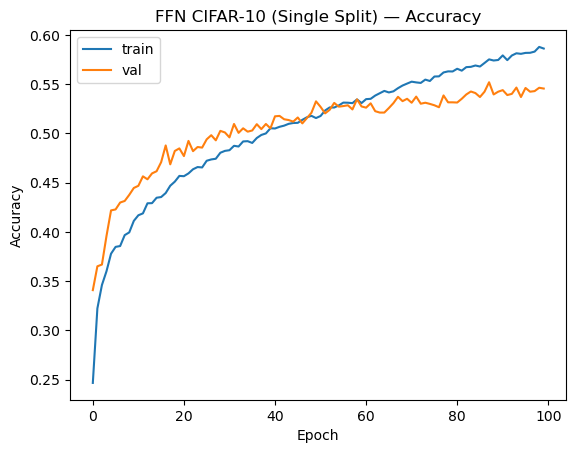

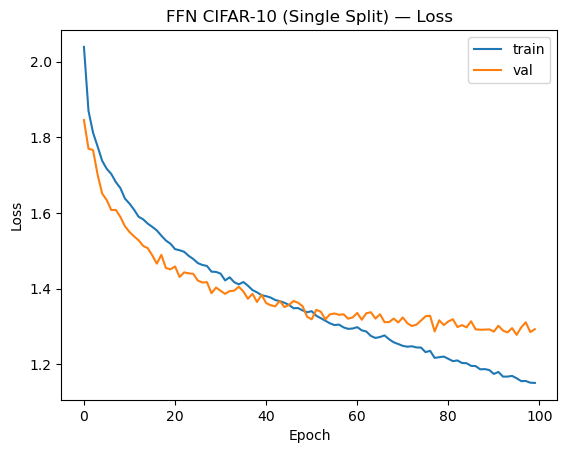

In [12]:
# Curvas de aprendizaje (entrenamiento simple)

import matplotlib.pyplot as plt

def plot_history(hist: tf.keras.callbacks.History, title_prefix: str = "") -> None:
    h = hist.history

    # Accuracy
    plt.figure()
    plt.plot(h["accuracy"])
    plt.plot(h["val_accuracy"])
    plt.title(f"{title_prefix}Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["train", "val"])
    plt.show()

    # Loss
    plt.figure()
    plt.plot(h["loss"])
    plt.plot(h["val_loss"])
    plt.title(f"{title_prefix}Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["train", "val"])
    plt.show()

plot_history(history, title_prefix="FFN CIFAR-10 (Single Split) — ")


## Interpretación 

### Desempeño
- Al final de 100 épocas se obtuvo:
  - `train accuracy` ≈ 0.586
  - `val accuracy` ≈ 0.546
  - `test accuracy` ≈ 0.536

Este desempeño es consistente con una **red feed-forward** (MLP) sobre CIFAR-10: al aplanar la imagen (`Flatten`) se pierde la estructura espacial, por lo que suele rendir peor que una CNN.

### Curvas de aprendizaje — Accuracy
- La curva de entrenamiento crece de forma sostenida hasta ~0.59.
- La curva de val crece hasta ~0.54–0.55 y luego se estabiliza.
- La diferencia entre train y val al final sugiere **sobreajuste moderado** (el modelo aprende patrones del conjunto de entrenamiento que no generalizan completamente).

### Curvas de aprendizaje — Loss
- La pérdida de entrenamiento disminuye continuamente.
- La pérdida de test disminuye al inicio y después se **aplana** alrededor de ~1.28–1.31.
- Este patrón confirma que, tras cierto punto, entrenar más épocas mejora principalmente el conjunto de entrenamiento, pero aporta poco a val (generalización limitada).

In [8]:
# Cross-Validation 5 Folds

from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.utils import to_categorical

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

fold_histories = []
fold_val_acc = []
fold_val_loss = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train_1d), start=1):
    print(f"\n===== Fold {fold}/5 =====")

    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train_1d[train_idx], y_train_1d[val_idx]

    y_tr_oh = to_categorical(y_tr, num_classes)
    y_val_oh = to_categorical(y_val, num_classes)

    # Importante: reconstruir el modelo en cada fold
    tf.random.set_seed(SEED)
    model_cv = build_ffn_model(input_shape=input_shape, num_classes=num_classes)

    model_cv.compile(
        optimizer=SGD(learning_rate=0.01, momentum=0.9),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    hist = model_cv.fit(
        X_tr, y_tr_oh,
        validation_data=(X_val, y_val_oh),
        epochs=100,
        batch_size=128,
        verbose=0
    )

    fold_histories.append(hist.history)

    best_val_acc = float(np.max(hist.history["val_accuracy"]))
    best_val_loss = float(np.min(hist.history["val_loss"]))
    fold_val_acc.append(best_val_acc)
    fold_val_loss.append(best_val_loss)

    print(f"Best val_accuracy: {best_val_acc:.4f} | Best val_loss: {best_val_loss:.4f}")

print("\n===== Resumen CV (5-fold) =====")
print("Val accuracy (best por fold):", np.round(fold_val_acc, 4))
print("Promedio val accuracy:", round(float(np.mean(fold_val_acc)), 4))
print("Std val accuracy:", round(float(np.std(fold_val_acc)), 4))



===== Fold 1/5 =====
Best val_accuracy: 0.5295 | Best val_loss: 1.3362

===== Fold 2/5 =====
Best val_accuracy: 0.5464 | Best val_loss: 1.2940

===== Fold 3/5 =====
Best val_accuracy: 0.5371 | Best val_loss: 1.3020

===== Fold 4/5 =====
Best val_accuracy: 0.5299 | Best val_loss: 1.3279

===== Fold 5/5 =====
Best val_accuracy: 0.5339 | Best val_loss: 1.3166

===== Resumen CV (5-fold) =====
Val accuracy (best por fold): [0.5295 0.5464 0.5371 0.5299 0.5339]
Promedio val accuracy: 0.5354
Std val accuracy: 0.0062


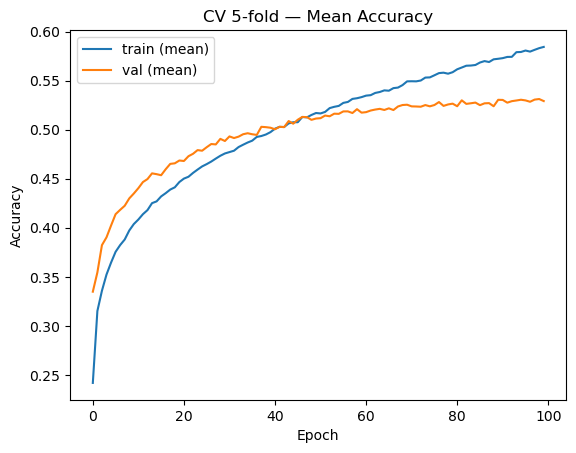

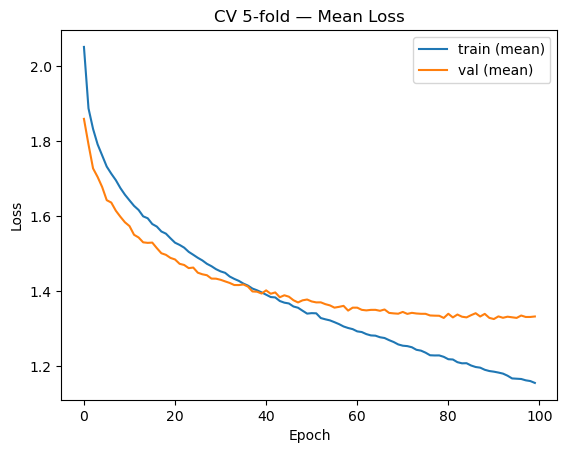

In [14]:
# Curvas de aprendizaje en CV

def mean_curve(histories: list[dict], key: str) -> np.ndarray:
    curves = np.array([h[key] for h in histories])  # shape: (folds, epochs)
    return curves.mean(axis=0)

mean_train_acc = mean_curve(fold_histories, "accuracy")
mean_val_acc = mean_curve(fold_histories, "val_accuracy")
mean_train_loss = mean_curve(fold_histories, "loss")
mean_val_loss = mean_curve(fold_histories, "val_loss")

# Accuracy
plt.figure()
plt.plot(mean_train_acc)
plt.plot(mean_val_acc)
plt.title("CV 5-fold — Mean Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["train (mean)", "val (mean)"])
plt.show()

# Loss
plt.figure()
plt.plot(mean_train_loss)
plt.plot(mean_val_loss)
plt.title("CV 5-fold — Mean Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["train (mean)", "val (mean)"])
plt.show()


Se realizó **validación cruzada estratificada de 5 folds** sobre el conjunto de entrenamiento, reconstruyendo y re-entrenando el modelo desde cero en cada fold (100 épocas por fold).  
En cada fold se reportó el **mejor** `val_accuracy` alcanzado durante el entrenamiento.



El desempeño promedio en validación es de ~0.535 con variación baja (std ~0.006), lo que sugiere que el modelo es relativamente estable entre particiones, aunque con un rendimiento limitado (esperable en CIFAR-10 con una red feed-forward).



## Curvas promedio de aprendizaje (CV 5-fold)

### Mean Accuracy (train vs val)
- La exactitud promedio de entrenamiento aumenta de manera sostenida y llega cerca de ~0.58 al final.
- La exactitud promedio de validación crece al inicio y luego se estabiliza alrededor de ~0.53–0.54.
- La brecha train–val al final indica **sobreajuste moderado**: el modelo sigue mejorando en entrenamiento, pero generaliza poco más en validación tras cierto punto.

### Mean Loss (train vs val)
- La pérdida promedio de entrenamiento disminuye continuamente.
- La pérdida promedio de validación disminuye al inicio y luego se **aplana** (≈ 1.33–1.35 al final).
- Este patrón confirma que, después de cierto número de épocas, entrenar más mejora principalmente el ajuste al conjunto de entrenamiento, con ganancias marginales en validación.

El comportamiento observado (val accuracy ~0.53–0.55) es consistente con una red **FFN** aplicada a imágenes de CIFAR-10, ya que el aplanado (`Flatten`) pierde la estructura espacial. Para mejoras sustanciales normalmente se emplean **CNNs**, que explotan patrones locales mediante convoluciones.


Ahora: 
1. Propongan una Red Convolucional con mejor Accuracy en el Cross-Validation con 5 Folds 
2. ¿Por qué encontran un mejor modelo contra la Feed-Forward?

In [1]:
# Importamos paquetes y configuración

import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.optimizer.set_jit(True)

BATCH_SIZE = 512  # clave para acelerar en CPU
EPOCHS = 100
NUM_CLASSES = 10

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def make_ds(X, y_oh, training: bool):
    ds = tf.data.Dataset.from_tensor_slices((X, y_oh))
    if training:
        ds = ds.shuffle(10_000, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


2026-02-08 20:06:19.527871: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
# CNN “light”, ya que el otro tardaba mucho en correr

from tensorflow.keras import layers, models

def build_cnn_light(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.20),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.40),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

input_shape = X_train.shape[1:]


In [8]:
# 5-fold CV

cnn_fold_best_val_acc = []
cnn_fold_best_val_loss = []
cnn_fold_histories = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train_1d), start=1):
    print(f"\n===== CNN (light) Fold {fold}/5 =====")

    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train_1d[train_idx], y_train_1d[val_idx]

    y_tr_oh = to_categorical(y_tr, NUM_CLASSES)
    y_val_oh = to_categorical(y_val, NUM_CLASSES)

    ds_tr = make_ds(X_tr, y_tr_oh, training=True)
    ds_val = make_ds(X_val, y_val_oh, training=False)

    tf.random.set_seed(SEED)
    cnn_model = build_cnn_light(input_shape=input_shape, num_classes=NUM_CLASSES)

    cnn_model.compile(
        optimizer=SGD(learning_rate=0.01, momentum=0.9),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    hist = cnn_model.fit(
        ds_tr,
        validation_data=ds_val,
        epochs=EPOCHS,
        verbose=2
    )

    cnn_fold_histories.append(hist.history)

    best_val_acc = float(np.max(hist.history["val_accuracy"]))
    best_val_loss = float(np.min(hist.history["val_loss"]))
    cnn_fold_best_val_acc.append(best_val_acc)
    cnn_fold_best_val_loss.append(best_val_loss)

    print(f"Best val_accuracy: {best_val_acc:.4f} | Best val_loss: {best_val_loss:.4f}")

print("\n===== Resumen CNN (light) CV (5-fold) =====")
print("Val accuracy (best por fold):", np.round(cnn_fold_best_val_acc, 4))
print("Promedio val accuracy:", round(float(np.mean(cnn_fold_best_val_acc)), 4))
print("Std val accuracy:", round(float(np.std(cnn_fold_best_val_acc)), 4))



===== CNN (light) Fold 1/5 =====
Epoch 1/100
79/79 - 20s - 257ms/step - accuracy: 0.1400 - loss: 2.2684 - val_accuracy: 0.2199 - val_loss: 2.1998
Epoch 2/100
79/79 - 20s - 256ms/step - accuracy: 0.2230 - loss: 2.0780 - val_accuracy: 0.2768 - val_loss: 2.0092
Epoch 3/100
79/79 - 20s - 253ms/step - accuracy: 0.2752 - loss: 1.9701 - val_accuracy: 0.3280 - val_loss: 1.8908
Epoch 4/100
79/79 - 19s - 246ms/step - accuracy: 0.3248 - loss: 1.8462 - val_accuracy: 0.3793 - val_loss: 1.7369
Epoch 5/100
79/79 - 19s - 247ms/step - accuracy: 0.3613 - loss: 1.7513 - val_accuracy: 0.3925 - val_loss: 1.6634
Epoch 6/100
79/79 - 19s - 245ms/step - accuracy: 0.3862 - loss: 1.6848 - val_accuracy: 0.3780 - val_loss: 1.7226
Epoch 7/100
79/79 - 19s - 246ms/step - accuracy: 0.4114 - loss: 1.6187 - val_accuracy: 0.4332 - val_loss: 1.5694
Epoch 8/100
79/79 - 20s - 256ms/step - accuracy: 0.4291 - loss: 1.5661 - val_accuracy: 0.4546 - val_loss: 1.5021
Epoch 9/100
79/79 - 20s - 254ms/step - accuracy: 0.4436 - loss

Epoch 73/100
79/79 - 20s - 255ms/step - accuracy: 0.7367 - loss: 0.7455 - val_accuracy: 0.7526 - val_loss: 0.7038
Epoch 74/100
79/79 - 20s - 257ms/step - accuracy: 0.7377 - loss: 0.7421 - val_accuracy: 0.7579 - val_loss: 0.6869
Epoch 75/100
79/79 - 20s - 255ms/step - accuracy: 0.7392 - loss: 0.7390 - val_accuracy: 0.7582 - val_loss: 0.6825
Epoch 76/100
79/79 - 20s - 258ms/step - accuracy: 0.7408 - loss: 0.7358 - val_accuracy: 0.7517 - val_loss: 0.6962
Epoch 77/100
79/79 - 22s - 272ms/step - accuracy: 0.7402 - loss: 0.7325 - val_accuracy: 0.7550 - val_loss: 0.6908
Epoch 78/100
79/79 - 23s - 290ms/step - accuracy: 0.7471 - loss: 0.7197 - val_accuracy: 0.7561 - val_loss: 0.6872
Epoch 79/100
79/79 - 22s - 273ms/step - accuracy: 0.7466 - loss: 0.7173 - val_accuracy: 0.7602 - val_loss: 0.6827
Epoch 80/100
79/79 - 21s - 269ms/step - accuracy: 0.7520 - loss: 0.7056 - val_accuracy: 0.7564 - val_loss: 0.6866
Epoch 81/100
79/79 - 21s - 272ms/step - accuracy: 0.7500 - loss: 0.7105 - val_accuracy: 

Epoch 45/100
79/79 - 22s - 274ms/step - accuracy: 0.6827 - loss: 0.9021 - val_accuracy: 0.7068 - val_loss: 0.8347
Epoch 46/100
79/79 - 22s - 282ms/step - accuracy: 0.6806 - loss: 0.9043 - val_accuracy: 0.7179 - val_loss: 0.8017
Epoch 47/100
79/79 - 24s - 300ms/step - accuracy: 0.6845 - loss: 0.8958 - val_accuracy: 0.7157 - val_loss: 0.8065
Epoch 48/100
79/79 - 24s - 310ms/step - accuracy: 0.6873 - loss: 0.8819 - val_accuracy: 0.7228 - val_loss: 0.7988
Epoch 49/100
79/79 - 23s - 289ms/step - accuracy: 0.6876 - loss: 0.8824 - val_accuracy: 0.7235 - val_loss: 0.7840
Epoch 50/100
79/79 - 23s - 290ms/step - accuracy: 0.6970 - loss: 0.8642 - val_accuracy: 0.7258 - val_loss: 0.7830
Epoch 51/100
79/79 - 24s - 305ms/step - accuracy: 0.6936 - loss: 0.8663 - val_accuracy: 0.7322 - val_loss: 0.7677
Epoch 52/100
79/79 - 24s - 302ms/step - accuracy: 0.6972 - loss: 0.8534 - val_accuracy: 0.7289 - val_loss: 0.7720
Epoch 53/100
79/79 - 23s - 287ms/step - accuracy: 0.7014 - loss: 0.8506 - val_accuracy: 

Epoch 17/100
79/79 - 21s - 265ms/step - accuracy: 0.5244 - loss: 1.3223 - val_accuracy: 0.5683 - val_loss: 1.2188
Epoch 18/100
79/79 - 20s - 257ms/step - accuracy: 0.5300 - loss: 1.3133 - val_accuracy: 0.5833 - val_loss: 1.1957
Epoch 19/100
79/79 - 20s - 258ms/step - accuracy: 0.5376 - loss: 1.2892 - val_accuracy: 0.5525 - val_loss: 1.2685
Epoch 20/100
79/79 - 20s - 258ms/step - accuracy: 0.5449 - loss: 1.2738 - val_accuracy: 0.5943 - val_loss: 1.1520
Epoch 21/100
79/79 - 21s - 264ms/step - accuracy: 0.5542 - loss: 1.2395 - val_accuracy: 0.6145 - val_loss: 1.1166
Epoch 22/100
79/79 - 22s - 281ms/step - accuracy: 0.5625 - loss: 1.2187 - val_accuracy: 0.6152 - val_loss: 1.1083
Epoch 23/100
79/79 - 23s - 291ms/step - accuracy: 0.5677 - loss: 1.2106 - val_accuracy: 0.6224 - val_loss: 1.0939
Epoch 24/100
79/79 - 21s - 262ms/step - accuracy: 0.5714 - loss: 1.1984 - val_accuracy: 0.6286 - val_loss: 1.0774
Epoch 25/100
79/79 - 21s - 261ms/step - accuracy: 0.5779 - loss: 1.1794 - val_accuracy: 

Epoch 89/100
79/79 - 21s - 260ms/step - accuracy: 0.7606 - loss: 0.6769 - val_accuracy: 0.7707 - val_loss: 0.6489
Epoch 90/100
79/79 - 21s - 260ms/step - accuracy: 0.7608 - loss: 0.6807 - val_accuracy: 0.7651 - val_loss: 0.6548
Epoch 91/100
79/79 - 21s - 265ms/step - accuracy: 0.7638 - loss: 0.6677 - val_accuracy: 0.7579 - val_loss: 0.6789
Epoch 92/100
79/79 - 20s - 256ms/step - accuracy: 0.7621 - loss: 0.6760 - val_accuracy: 0.7770 - val_loss: 0.6361
Epoch 93/100
79/79 - 20s - 251ms/step - accuracy: 0.7645 - loss: 0.6644 - val_accuracy: 0.7765 - val_loss: 0.6306
Epoch 94/100
79/79 - 20s - 254ms/step - accuracy: 0.7633 - loss: 0.6662 - val_accuracy: 0.7730 - val_loss: 0.6378
Epoch 95/100
79/79 - 21s - 260ms/step - accuracy: 0.7662 - loss: 0.6608 - val_accuracy: 0.7800 - val_loss: 0.6306
Epoch 96/100
79/79 - 20s - 257ms/step - accuracy: 0.7688 - loss: 0.6564 - val_accuracy: 0.7684 - val_loss: 0.6531
Epoch 97/100
79/79 - 21s - 261ms/step - accuracy: 0.7684 - loss: 0.6520 - val_accuracy: 

Epoch 61/100
79/79 - 21s - 261ms/step - accuracy: 0.7170 - loss: 0.7995 - val_accuracy: 0.7483 - val_loss: 0.7339
Epoch 62/100
79/79 - 20s - 254ms/step - accuracy: 0.7212 - loss: 0.7939 - val_accuracy: 0.7471 - val_loss: 0.7321
Epoch 63/100
79/79 - 20s - 255ms/step - accuracy: 0.7196 - loss: 0.7889 - val_accuracy: 0.7432 - val_loss: 0.7462
Epoch 64/100
79/79 - 21s - 271ms/step - accuracy: 0.7255 - loss: 0.7764 - val_accuracy: 0.7557 - val_loss: 0.7144
Epoch 65/100
79/79 - 21s - 260ms/step - accuracy: 0.7256 - loss: 0.7783 - val_accuracy: 0.7489 - val_loss: 0.7309
Epoch 66/100
79/79 - 21s - 267ms/step - accuracy: 0.7287 - loss: 0.7650 - val_accuracy: 0.7462 - val_loss: 0.7320
Epoch 67/100
79/79 - 21s - 263ms/step - accuracy: 0.7329 - loss: 0.7643 - val_accuracy: 0.7562 - val_loss: 0.7229
Epoch 68/100
79/79 - 21s - 260ms/step - accuracy: 0.7304 - loss: 0.7627 - val_accuracy: 0.7551 - val_loss: 0.7075
Epoch 69/100
79/79 - 21s - 265ms/step - accuracy: 0.7326 - loss: 0.7600 - val_accuracy: 

Epoch 33/100
79/79 - 20s - 251ms/step - accuracy: 0.6313 - loss: 1.0275 - val_accuracy: 0.6747 - val_loss: 0.9405
Epoch 34/100
79/79 - 20s - 253ms/step - accuracy: 0.6349 - loss: 1.0303 - val_accuracy: 0.6846 - val_loss: 0.9250
Epoch 35/100
79/79 - 20s - 253ms/step - accuracy: 0.6392 - loss: 1.0125 - val_accuracy: 0.6875 - val_loss: 0.9024
Epoch 36/100
79/79 - 19s - 246ms/step - accuracy: 0.6464 - loss: 0.9955 - val_accuracy: 0.6823 - val_loss: 0.9032
Epoch 37/100
79/79 - 20s - 255ms/step - accuracy: 0.6473 - loss: 0.9923 - val_accuracy: 0.6951 - val_loss: 0.8840
Epoch 38/100
79/79 - 20s - 257ms/step - accuracy: 0.6544 - loss: 0.9736 - val_accuracy: 0.7000 - val_loss: 0.8692
Epoch 39/100
79/79 - 21s - 261ms/step - accuracy: 0.6603 - loss: 0.9591 - val_accuracy: 0.7008 - val_loss: 0.8602
Epoch 40/100
79/79 - 26s - 332ms/step - accuracy: 0.6561 - loss: 0.9599 - val_accuracy: 0.6951 - val_loss: 0.8752
Epoch 41/100
79/79 - 23s - 294ms/step - accuracy: 0.6614 - loss: 0.9503 - val_accuracy: 

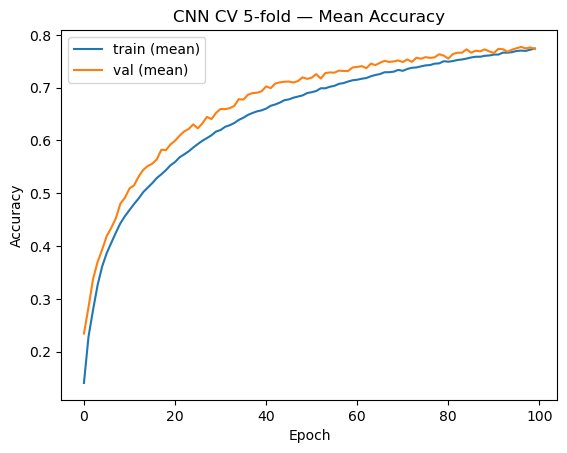

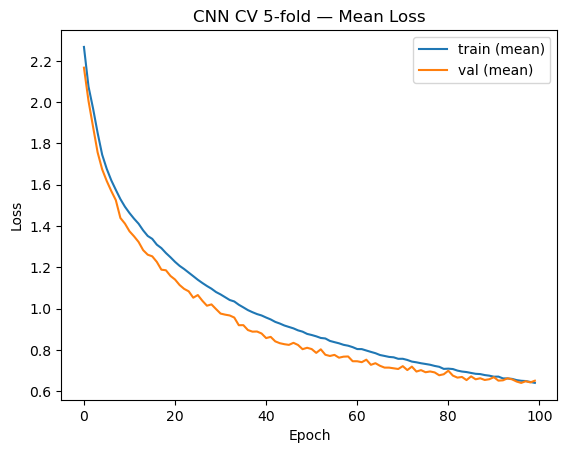

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def mean_curve(histories, key):
    curves = np.array([h[key] for h in histories])  # (folds, epochs)
    return curves.mean(axis=0)

cnn_mean_train_acc  = mean_curve(cnn_fold_histories, "accuracy")
cnn_mean_val_acc    = mean_curve(cnn_fold_histories, "val_accuracy")
cnn_mean_train_loss = mean_curve(cnn_fold_histories, "loss")
cnn_mean_val_loss   = mean_curve(cnn_fold_histories, "val_loss")

# Accuracy
plt.figure()
plt.plot(cnn_mean_train_acc)
plt.plot(cnn_mean_val_acc)
plt.title("CNN CV 5-fold — Mean Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["train (mean)", "val (mean)"])
plt.show()

# Loss
plt.figure()
plt.plot(cnn_mean_train_loss)
plt.plot(cnn_mean_val_loss)
plt.title("CNN CV 5-fold — Mean Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["train (mean)", "val (mean)"])
plt.show()


Se entrenó una **Red Convolucional (CNN)** con 5-fold Cross-Validation (100 épocas por fold), usando como métrica `accuracy` y reportando el **mejor `val_accuracy` por fold**.

### Resumen numérico (validación)
Mejor `val_accuracy` por fold:
$$[0.7801,\ 0.7815,\ 0.7800,\ 0.7860,\ 0.7759]$$

Promedio de `val_accuracy` (best por fold):
$$\bar{a}_{val} = 0.7807$$

Desviación estándar:
$$s_{val} = 0.0032$$

**Interpretación:** el desempeño promedio en validación es alto (~0.781) y la variabilidad entre folds es baja (std ~0.003), lo que sugiere un modelo **estable** y con buena generalización bajo particiones distintas.


## Curvas promedio de aprendizaje (CV 5-fold)

### Mean Accuracy
La curva promedio de `val_accuracy` crece de forma sostenida hasta ~0.78 y se mantiene cercana a la curva de entrenamiento al final.  
La brecha train–val es pequeña, indicando **bajo sobreajuste** comparado con el modelo Feed-Forward.

### Mean Loss
La pérdida promedio (`loss`) disminuye tanto en entrenamiento como en validación hasta ~0.65 al final.  
Esto es consistente con un entrenamiento estable y una mejora sostenida de la generalización.

---

## Comparación: CNN vs Feed-Forward (FFN)

En la FFN (MLP) con CV 5-fold se obtuvo aproximadamente:
$$\bar{a}_{val}^{FFN} \approx 0.5354$$

En la CNN (light) con CV 5-fold se obtuvo:
$$\bar{a}_{val}^{CNN} = 0.7807$$

La ganancia absoluta aproximada es:
$$\Delta = \bar{a}_{val}^{CNN} - \bar{a}_{val}^{FFN} \approx 0.7807 - 0.5354 = 0.2453$$

**Conclusión:** la CNN supera claramente a la FFN en validación cruzada, con una mejora de ~0.245 en accuracy promedio.

---

## ¿Por qué la CNN es mejor que la Feed-Forward?

1) **Preserva la estructura espacial**: las convoluciones exploran vecindarios locales (bordes, texturas) manteniendo la geometría 2D; la FFN con `Flatten` pierde esa información espacial.

2) **Compartición de pesos**: los filtros convolucionales reutilizan parámetros en toda la imagen, reduciendo complejidad efectiva y mejorando generalización.

3) **Aprendizaje jerárquico de características**: capas convolucionales apiladas aprenden representaciones de bajo a alto nivel (bordes → patrones → partes/objetos), lo que es especialmente útil en CIFAR-10.

# `lec07-Recurrent Neural Network`

**Parte Teórica**

1. ¿Qué es una Red Recurrente?

Una **Red Neuronal Recurrente (RNN)** es una red diseñada para modelar **secuencias** (por ejemplo, series de tiempo). A diferencia de una red *feed-forward* que procesa observaciones independientes, una RNN incorpora **conexiones recurrentes** que permiten que la salida (o el **estado oculto**) en el tiempo \(t\) influya en el procesamiento del tiempo \(t+1\).  
Intuitivamente, una RNN puede verse como una red con memoria: va acumulando información de la secuencia conforme avanza.


2. ¿Por qué esta Red es diferente a las que hemos visto antes?

Es diferente a una *feed-forward* por tres razones principales:

1. **Dependencia temporal:** la predicción en t depende no solo del input actual, sino también del **historial** (estado oculto) aprendido de tiempos anteriores.
2. **Pesos compartidos en el tiempo:** la misma transformación (mismos pesos) se aplica repetidamente para cada paso temporal, lo que permite generalizar a secuencias (y reduce parámetros vs “una red distinta por cada t”).
3. **Entrada/salida en formato secuencial:** trabaja naturalmente con datos tipo muestras, pasos temporales, features, a diferencia del vector fijo típico en *feed-forward*.


3. ¿Qué problemas hay que solucionar para aplicar este tipo de Red?


a. **Entrenamiento con dependencias temporales (Backpropagation Through Time, BPTT):**  
   Para poder aplicar backpropagation en una red con ciclos, la RNN se **despliega/desenvuelve en el tiempo**, convirtiéndola en una estructura tipo *feed-forward* sobre varios pasos temporales, y entonces se aplica backpropagation.

b. **Inestabilidad de gradientes (gradiente que desaparece o explota):**  
   Al hacer backpropagation sobre muchos pasos temporales, los gradientes pueden volverse **muy pequeños** (desaparecen) o **muy grandes** (explotan), haciendo el entrenamiento inestable.  
   Este problema motiva el uso de arquitecturas como **LSTM**, que permiten un flujo de gradiente más estable para aprender dependencias de más largo plazo.


4. ¿Qué es LSTM y por qué se dice qué es más "inteligente" que las neuoronas de una Red Feed-Forward?

**LSTM (Long Short-Term Memory)** es una variante de RNN que reemplaza neuronas simples por **bloques de memoria**.  
Cada bloque incluye una **celda de memoria** y **puertas (gates)** que controlan qué información:

- se **guarda** (input gate),
- se **olvida** (forget gate),
- y se **expone** como salida (output gate).

Se dice que es más inteligente porque no solo transforma inputs: **administra memoria** de manera selectiva, lo que ayuda a **mitigar el gradiente que desaparece** y a capturar patrones de largo plazo que una ventana fija (enfoque ingenuo con *feed-forward*) típicamente no logra.


5. ¿Cuáles fueron las diferentes versiones que vimos de LSTM? Es decir, diferentes configuraciones que hicimos. 

En el notebook se implementan varias configuraciones de LSTM, principalmente variando **(i)** la **forma del input** y **(ii)** el **modo de entrenamiento**.

**a) LSTM “simple” (look-back tratado como *features*)**  
- Ventana: `look_back` (p.ej., 2 rezagos).  
- **Input (Keras):** `(samples, 1, look_back)`  
- **Modelo:** `LSTM(4, input_shape=(1, look_back)) -> Dense(1)`

**b) Misma arquitectura, cambiando hiperparámetros de entrenamiento**  
- Se mantiene la arquitectura de (a), pero se ajustan hiperparámetros como **número de épocas** (p.ej., 25 vs 50) para evaluar impacto en el ajuste.

**c) LSTM con input como secuencia (look-back tratado como *pasos temporales*)**  
- `look_back` se interpreta como **time steps**.  
- **Input (Keras):** `(samples, look_back, 1)`  
- **Modelo:** `LSTM(4, input_shape=(look_back, 1)) -> Dense(1)`

**d) LSTM *stateful* (estado persistente entre batches)**  
- Se fija `batch_size` y se activa memoria entre lotes (`stateful=True`).  
- **Input (Keras):** `(batch_size, look_back, 1)`  *(batch_shape fijo)*  
- **Modelo:** `LSTM(4, batch_input_shape=(batch_size, look_back, 1), stateful=True) -> Dense(1)`  
- Se entrena en un loop de épocas (una época a la vez) y se controla el estado (p.ej., reinicio de estados cuando aplica).

**Parte Práctica**
1. Utilicen el API de yahoo finance y  descarguen el ETF del S&P500 (SPY): 
`data=yf.download("SPY",start="2016-01-01",end="2026-01-31")`

2. De acuerdo a la visto en clase utilicen una Red LSTM. 

3. Definan todo el 2016 hasta el 2024 como su Training Data Set y calibren su modelo.

4. Pronostiquen todo el 2025 y 2026. 

3. Utilicen `mean_squared_error` para compilar y el Optimizador que deseen. 

4. Utilicen epochs que consideren y que sean online ( batch_size=1)

5. Calculen el RMSE Error Cuadrático Medio del Train y Test

6. Grafiquen su pronóstico en Train y Test.

7. ¿Por qué creen que obtuvieron ese resultado? ¿Cómo lo mejorarían?

In [1]:
# Descargamos SPY con Yahoo Finance. Importamos paquetes y librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam


data = yf.download("SPY", start="2016-01-01", end="2026-01-31", auto_adjust=False)
data = data.dropna()

# Usaremos el precio de cierre ajustado para series financieras
series = data[["Adj Close"]].rename(columns={"Adj Close": "price"}).copy()
series.head()


2026-02-09 11:03:33.216652: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[*********************100%***********************]  1 of 1 completed


Price,price
Ticker,SPY
Date,
2016-01-04,170.372177
2016-01-05,170.660385
2016-01-06,168.507614
2016-01-07,164.464844
2016-01-08,162.659531


In [2]:
# Dividimos el data set. Split temporal: Train (2016–2024) / Test (2025–2026)

train = series.loc["2016-01-01":"2024-12-31"].copy()
test  = series.loc["2025-01-01":"2026-01-31"].copy()

print("Train:", train.index.min().date(), "->", train.index.max().date(), "| n =", len(train))
print("Test :", test.index.min().date(),  "->", test.index.max().date(),  "| n =", len(test))


Train: 2016-01-04 -> 2024-12-31 | n = 2264
Test : 2025-01-02 -> 2026-01-30 | n = 270


In [3]:
# Escalamiento (fit SOLO en train)

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train[["price"]].values)
test_scaled = scaler.transform(test[["price"]].values)  # solo transform, sin fit

train_scaled.shape, test_scaled.shape


((2264, 1), (270, 1))

In [4]:
# Ventanas look-back (supervised learning)

def create_dataset(values: np.ndarray, look_back: int) -> tuple[np.ndarray, np.ndarray]:
    """
    values: array de forma (n, 1) escalado
    Devuelve:
      X: (n-look_back, look_back, 1)
      y: (n-look_back, 1)
    """
    X, y = [], []
    for i in range(look_back, len(values)):
        X.append(values[i - look_back:i, 0])
        y.append(values[i, 0])
    X = np.array(X).reshape(-1, look_back, 1)
    y = np.array(y).reshape(-1, 1)
    return X, y

look_back = 20  # ventana típica (aprox. 1 mes de trading)
X_train, y_train = create_dataset(train_scaled, look_back)
X_test, y_test = create_dataset(test_scaled, look_back)

X_train.shape, y_train.shape, X_test.shape, y_test.shape


((2244, 20, 1), (2244, 1), (250, 20, 1), (250, 1))

In [5]:
# Realizamos la red LSTM + compilación con MSE y optimizador

model = Sequential([
    LSTM(50, input_shape=(look_back, 1)),
    Dense(1)
])

model.compile(
    loss="mean_squared_error",     # requisito: mean_squared_error
    optimizer=Adam(learning_rate=0.001)  # el optimizador que deseemos
)

model.summary()


/Users/andrespadronquintana/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Entrenamos con batch_size=1

epochs = 20  # ajustar si se desea
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=1,     
    verbose=1,
    shuffle=False     
)


Epoch 1/20
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 2.2260e-04
Epoch 2/20
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 5.6730e-04
Epoch 3/20
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 4.2312e-04
Epoch 4/20
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 2.7822e-04
Epoch 5/20
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 2.0160e-04
Epoch 6/20
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.6562e-04
Epoch 7/20
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.5562e-04
Epoch 8/20
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.4525e-04
Epoch 9/20
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.4204e-04
Epoch 10/20
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.3442e-04
Epoch 11/20
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.2077e-04
Epoch 12/20
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.1110e-04
Epoch 13/20
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.1097e-04
Epoch 14/20
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 6s 3

In [7]:
# 7) Predicción + RMSE en Train y Test (2025–2026)


# Predicciones en escala [0,1]
train_pred_scaled = model.predict(X_train, batch_size=1, verbose=0)
test_pred_scaled  = model.predict(X_test,  batch_size=1, verbose=0)

# Invertir escalamiento a precios reales
train_pred = scaler.inverse_transform(train_pred_scaled)
test_pred  = scaler.inverse_transform(test_pred_scaled)

y_train_real = scaler.inverse_transform(y_train)
y_test_real  = scaler.inverse_transform(y_test)

rmse_train = np.sqrt(mean_squared_error(y_train_real, train_pred))
rmse_test  = np.sqrt(mean_squared_error(y_test_real,  test_pred))

print(f"RMSE Train (2016–2024): {rmse_train:,.4f}")
print(f"RMSE Test  (2025–2026): {rmse_test:,.4f}")


RMSE Train (2016–2024): 48.1214
RMSE Test  (2025–2026): 43.9010


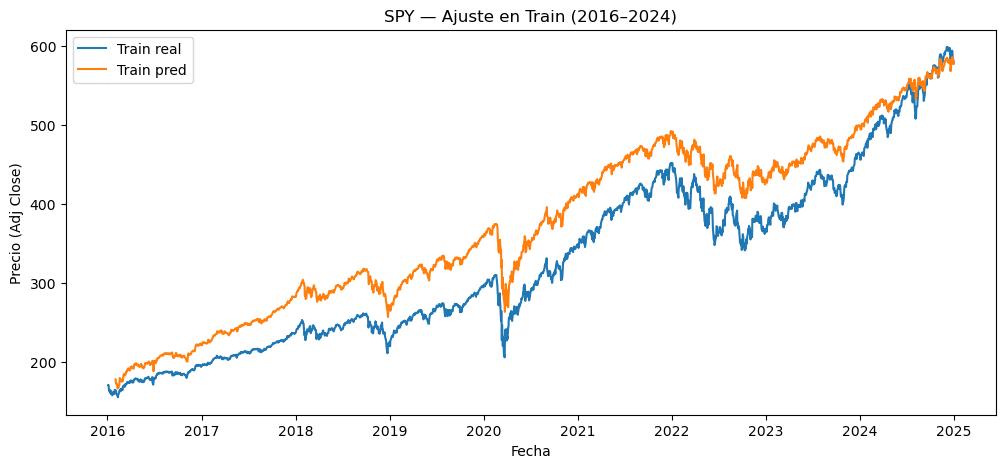

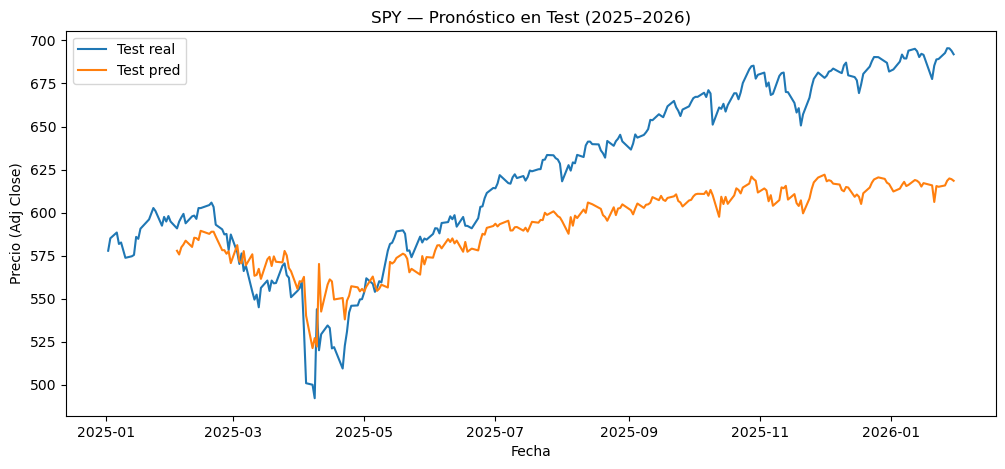

In [8]:
# 8) Graficamos pronóstico en Train y Test

train_plot = train.copy()
train_plot["pred"] = np.nan
train_plot.iloc[look_back:, train_plot.columns.get_loc("pred")] = train_pred.flatten()

test_plot = test.copy()
test_plot["pred"] = np.nan
test_plot.iloc[look_back:, test_plot.columns.get_loc("pred")] = test_pred.flatten()

plt.figure(figsize=(12, 5))
plt.plot(train_plot.index, train_plot["price"], label="Train real")
plt.plot(train_plot.index, train_plot["pred"], label="Train pred")
plt.title("SPY — Ajuste en Train (2016–2024)")
plt.xlabel("Fecha")
plt.ylabel("Precio (Adj Close)")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(test_plot.index, test_plot["price"], label="Test real")
plt.plot(test_plot.index, test_plot["pred"], label="Test pred")
plt.title("SPY — Pronóstico en Test (2025–2026)")
plt.xlabel("Fecha")
plt.ylabel("Precio (Adj Close)")
plt.legend()
plt.show()


### Métricas
Con la red LSTM entrenada en **2016–2024** y evaluada en **2025–2026**, obtuve:

- **RMSE Train (2016–2024):** 48.1214  
- **RMSE Test (2025–2026):** 43.9010  

Que el RMSE en **Test sea menor** que en Train puede ocurrir y no necesariamente es un error: el RMSE depende de la **volatilidad** y del **rango de precios** del periodo. Si el tramo 2025–2026 fue más suave (menos saltos o menos variación) que partes del periodo 2016–2024 (por ejemplo, el shock de la pandemia en 2020), entonces el error cuadrático medio puede salir menor aun cuando el modelo no generalice “mejor”.



### Gráficas

**(1) Ajuste en Train (2016–2024).**  
La predicción (línea naranja) sigue la tendencia general pero aparece **sesgada hacia arriba** respecto a la serie real (azul) durante buena parte del periodo. Además, en eventos de alta volatilidad (p. ej., caídas bruscas) el modelo **suaviza** el movimiento y no alcanza las caídas/picos con precisión.

**Lectura:** la LSTM está capturando nivel + tendencia pero no replica bien shocks y cambios bruscos. En precios financieros esto es común: el modelo aprende un pronóstico “promedio/suavizado”.

**(2) Pronóstico en Test (2025–2026).**  
En test, la predicción es claramente **más suave** y tiende a quedarse **por debajo** del nivel real en la parte final, es decir, hay **subestimación del nivel** (bias a la baja). También se observa **retraso**: la red responde lentamente a cambios.

El modelo tiene dificultad para extrapolar el aumento de nivel en 2025–2026; tiende a predecir una trayectoria amortiguada y con rezago.


### ¿Por qué  ese resultado?

1. **Predecir precio (nivel) es difícil y no estacionario.**  
   El precio de un ETF incorpora tendencia, cambios estructurales y shocks. Un LSTM con solo `Adj Close` y una ventana fija suele aprender una dinámica de corto plazo, pero no anticipa saltos.

2. **El escalamiento (MinMax) y la ventana inducen suavizado.**  
   Al entrenar sobre datos escalados y usar pérdida MSE, la solución típica minimiza errores grandes produciendo predicciones **conservadoras** (suaves), especialmente cuando hay ruido.

3. **Limitación de información.**  
   Usar solo el precio no incluye factores relevantes (volumen, volatilidad, rendimientos, indicadores técnicos/macro), por lo que la red aprende una señal limitada.


### ¿Cómo lo mejoraría? 

**Mejoras de formulación (lo más importante):**
- Modelar **retornos** (por ejemplo log-retornos) en lugar de precio para acercarse a estacionariedad y luego reconstruir el precio.
- En lugar de una sola variable, agregar features: retornos rezagados, volatilidad rolling, medias móviles, volumen.

**Mejoras del modelo/entrenamiento:**
- Probar **más unidades** o **stacked LSTM** (dos capas), y regularización (Dropout).
- Usar **EarlyStopping** y ajustar `learning_rate`.
- Ajustar `look_back` (p. ej., 20, 60, 120) y comparar RMSE.
- Validación tipo **walk-forward** para calibrar hiperparámetros sin contaminar el test.

**Mejoras de pronóstico:**
- Distinguir entre:
  - **one-step ahead** usando ventanas con datos reales del test (lo que hiciste), vs
  - **pronóstico recursivo multi-step** (usar la predicción como input para el siguiente paso), que es más exigente pero más “realista” para forecasting puro.

# `lec09-Reinforcement Learning`

**Parte Teórica**

1. ¿Qué es el modelo de DQN (Deep Q-Network)?

Un **DQN** es una versión de *Q-learning* donde la función de valor-acción se aproxima con una red neuronal:
$$
Q_\theta(s,a)\approx \mathbb{E}\Big[\sum_{k=0}^{\infty}\gamma^k r_{t+k}\ \Big|\ s_t=s,\ a_t=a\Big].
$$
La red recibe el **estado** $$s$$ y devuelve un vector con un valor $$Q_\theta(s,a)$$ para cada acción posible (p.ej. *buy/sell/hold*). La política elige típicamente $$\arg\max_a Q_\theta(s,a)$$, incorporando exploración con $$\epsilon$$-greedy.

2. ¿Por creen qué lo programamos con `Class`?

Porque el agente DQN y el entorno necesitan **estado interno** y métodos que deben encapsularse:

- Parámetros del agente: $$\gamma,\ \epsilon,\ \epsilon_{\min},\ \text{decay}$$, etc.
- Memoria de experiencias (*replay buffer*) con transiciones $$(s,a,r,s')$$.
- Métodos del agente: decidir acción, guardar experiencias, entrenar con *experience replay*.
- Entorno: generar estado y recompensa en cada paso.

Esto hace el código modular, reutilizable y consistente con el flujo del notebook.

3. ¿Qué Reward que usamos en el caso de SPY y en el Caso del Portafolio?

**Caso SPY (trading):** la recompensa se asocia al **PnL realizado**. La idea es:
- Si se **vende**, se materializa ganancia/pérdida:
$$
r_t = \text{PnL realizado en la venta}.
$$
- Si se **compra** o se **mantiene**, típicamente:
$$
r_t = 0,
$$
porque no se realiza el PnL en ese instante.

**Caso Portafolio (asignación):** la recompensa se basa en el desempeño del portafolio en el periodo:
- Con pesos $$w_t$$ (acción) y retornos del vector de activos $$R_{t+1}$$:
$$
r_t = w_t^\top R_{t+1}.
$$
Además, en el notebook se calcula el **Sharpe** como medida de calidad del periodo (retorno relativo a volatilidad), por lo que la recompensa puede interpretarse como “retorno del portafolio” y se reporta también el Sharpe como métrica de desempeño.

---


4. ¿Qué es la Q de Bellman?

La **ecuación de Bellman** para la función valor–acción óptima establece:

$$
Q^\star(s,a)=\mathbb{E}\Big[r_t+\gamma\max_{a'}Q^\star(s',a')\ \Big|\ s_t=s,\ a_t=a\Big].
$$

En **DQN**, esta relación se usa para construir un **target**. Para una transición $$ (s,a,r,s') $$ se define:

$$
y = r_t + \gamma\max_{a'}Q_{\theta}(s',a').
$$

Luego se ajustan los parámetros $$\theta$$ minimizando el error cuadrático:

$$
\min_{\theta}\ \Big(y - Q_{\theta}(s,a)\Big)^2.
$$

5. ¿Lo consideran Análisis Supervisado? 

No en sentido estricto: es **aprendizaje por refuerzo** (no hay etiquetas “correctas”).  
Sin embargo, el entrenamiento de la red sí se parece a supervisado porque se generan pares:
$$
(\text{input}=s,\ \text{target}=y),
$$
donde $$y$$ proviene de la ecuación de Bellman.


6. ¿Por qué dijimos que las salidas de la Red Neuornal para el caso de SPY era dinero y al mismo tiempo probabilidades?

La red produce **valores** $$Q_\theta(s,a)$$ que representan el **valor esperado descontado** de seguir una acción, por eso se interpretan como dinero/valor.

A la vez, esos valores pueden transformarse en una regla de decisión probabilística (por ejemplo con *softmax*):
$$
\pi(a\mid s)=\frac{e^{Q_\theta(s,a)}}{\sum_{b}e^{Q_\theta(s,b)}},
$$
lo que permite interpretar la preferencia por acciones como “probabilidades” (aunque el DQN típicamente decide con $$\arg\max$$ y exploración $$\epsilon$$-greedy).



7. En el caso del portafolio, ¿Qué diferencia le encuentran contra una Optimización Media-Varianza? ¿Por qué creen que estos modelos puden ser bien recibidos para Robo-Advisors, Fondos, etc?

**Media–Varianza (Markowitz)** es un problema estático que usa estimaciones de medias y covarianzas:
$$
\max_w\ \mu^\top w - \lambda\, w^\top \Sigma w.
$$
Es sensible a errores de estimación y puede producir pesos inestables.

**DQN para portafolios** aprende una **política dinámica** que maximiza recompensa acumulada:
$$
\max_\pi\ \mathbb{E}_\pi\Big[\sum_{t}\gamma^t r_t\Big],
$$
y puede incorporar naturalmente objetivos y restricciones reales (costos de transacción, drawdown, límites por activo) a través del reward y del entorno.

Esto es atractivo para **robo-advisors/fondos** porque automatiza decisiones secuenciales (rebalanceos) y puede adaptarse a cambios de régimen.


8. ¿Qué papel juega la Gamma y Epsilon?

- $$\gamma$$ (**descuento**) controla la importancia del futuro:
$$
\text{Mayor }\gamma \Rightarrow \text{más peso a recompensas futuras}.
$$
- $$\epsilon$$ (**exploración**) en $$\epsilon$$-greedy controla acciones aleatorias:
$$
a=
\begin{cases}
\text{acción aleatoria}, & \text{con prob. }\epsilon,\\
\arg\max_a Q_\theta(s,a), & \text{con prob. }1-\epsilon.
\end{cases}
$$
Normalmente $$\epsilon$$ decae durante el entrenamiento.

9. ¿De donde salen los pesos de su portafolio utilizando DQN? 

En el problema de portafolio, la **acción** representa la decisión de asignación.  
En cada estado $$s_t$$, el agente produce una acción que se interpreta como pesos $$w_t$$, y el entorno devuelve recompensa $$r_t$$ según el desempeño del portafolio. Con el entrenamiento, el agente aprende a seleccionar pesos que maximizan:
$$
\mathbb{E}\Big[\sum_t \gamma^t r_t\Big].
$$

10. ¿Qué recibe de Input el DQN del Portafolio y por qué?

El input (estado) se construye con información de una ventana histórica; en el notebook se usa como estado una representación tipo **matriz de covarianza** (de retornos) en la ventana:
$$
s_t = \Sigma_t.
$$
Esto es relevante porque $$\Sigma_t$$ resume riesgo conjunto y diversificación, que son claves para decidir pesos.


11. ¿Qué le mejorarían y por qué?

1. Reward más realista (costos de transacción, penalización por drawdown/volatilidad):
$$
r_t = w_t^\top R_{t+1} - c\cdot \text{turnover}_t - \lambda\cdot \sigma_t.
$$
2. Acciones continuas y restricciones explícitas:
$$
\sum_i w_i = 1,\quad w_i\ge 0 \ \ (\text{si no hay short}).
$$
3. Validación temporal (*walk-forward*) y robustez por regímenes.
4. Estado más informativo: además de $$\Sigma_t$$ incluir momentum, volatilidad, retornos esperados, etc.


12. Con sus palabras expliquen cómo podríamos usar DQN para un Portafolio de Inversión. ¿En qué se diferencia de Optimización Clásicas Media Varianza (Markowitz)?

*Uso de DQN:**
1. Definir el entorno con estado $$s_t$$ (p.ej. $$\Sigma_t$$), acción $$a_t$$ (pesos $$w_t$$) y reward $$r_t$$ (retorno/Sharpe/costos).
2. Entrenar al agente para aprender una política $$\pi(a\mid s)$$ que maximice recompensa acumulada:
$$
\max_\pi\ \mathbb{E}_\pi\Big[\sum_{t}\gamma^t r_t\Big].
$$
3. En operación, al observar $$s_t$$ se elige $$w_t$$ y se rebalancea.

**Diferencia vs Markowitz:**
- Markowitz es una optimización estática basada en $$\mu$$ y $$\Sigma$$.
- DQN aprende una política secuencial y puede incorporar objetivos/restricciones realistas en el reward y el entorno, adaptándose dinámicamente al mercado.

# `lec09-Reinforcement Learning (Individual)`

**Parte Práctica**
1. Utilicen la información del SPY (S&P500) con últimos diez años de Train. Usen 2025 y 2026 como Test. 
2. Entrenen su modelo con Reinforcement Learning como lo hicimos en clase: 3 señales: compra/mantener/venta. 
3. Grafiquen su modelo como lo hicimos en clase (train)
4. ¿Qué les diría al para mañana su modelo? "Compra/Venta/Mantener"
5. En clase probamos el modelo con el Train. Ahora prueban con el Test y Grafíquenlo. 
6. ¿Qué mejorarían al modelo?
7. ¿Qué cambiarían para poder agregar más variables al modelo?

In [10]:
# Cargamos Datos SPY + split Train/Test. Cargamos paquetes y librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from collections import deque
import random
import math

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

dataset = yf.download("SPY", start="2016-01-01", end="2026-01-31", auto_adjust=False).dropna()
series = dataset["Adj Close"].astype(float).copy()

train_series = series.loc["2016-01-01":"2024-12-31"].copy()
test_series  = series.loc["2025-01-01":"2026-01-31"].copy()

data_train = train_series.values.astype(float).tolist()
data_test  = test_series.values.astype(float).tolist()

print("Train:", train_series.index.min().date(), "->", train_series.index.max().date(), "| n =", len(train_series))
print("Test :", test_series.index.min().date(),  "->", test_series.index.max().date(),  "| n =", len(test_series))

[*********************100%***********************]  1 of 1 completed

Train: 2016-01-04 -> 2024-12-31 | n = 2264
Test : 2025-01-02 -> 2026-01-30 | n = 270


In [11]:
# Funciones auxiliares

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def formatPrice(n):
    return ("-$" if n < 0 else "$") + "{0:.2f}".format(abs(n))

def _to_float(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return float(np.asarray(x).ravel()[0])
    return float(x)

def getState(data, t, n):
    """
    Estado basado en diferencias de precio (normalizadas con sigmoid).
    Devuelve shape (1, n-1).
    """
    d = t - n + 1
    block = data[d:t+1] if d >= 0 else (-d) * [data[0]] + data[0:t+1]

    res = []
    for i in range(n - 1):
        x_next = _to_float(block[i + 1])
        x_curr = _to_float(block[i])
        res.append(sigmoid(x_next - x_curr))

    return np.array([res], dtype=np.float32)

In [12]:
# Agente (DQN) como en el notebook lec09

class Agent:
    def __init__(self, state_size, is_eval=False, model_name=""):
        self.state_size = state_size
        self.action_size = 3  # 0 hold, 1 buy, 2 sell
        self.memory = deque(maxlen=1000)
        self.inventory = []
        self.is_eval = is_eval

        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.10
        self.epsilon_decay = 0.995

        self.model = self._model()

    def _model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(units=64, activation="relu"),
            Dense(units=32, activation="relu"),
            Dense(units=8, activation="relu"),
            Dense(units=8, activation="relu"),
            Dense(self.action_size, activation="linear"),
        ])
        model.compile(loss="mse", optimizer=Adam())
        return model

    def act(self, state):
        if (not self.is_eval) and (np.random.rand() <= self.epsilon):
            return random.randrange(self.action_size)
        options = self.model.predict(state, verbose=0)
        return int(np.argmax(options[0]))

    def expReplay(self, batch_size):
        mini_batch = []
        l = len(self.memory)

        for i in range(l - batch_size + 1, l):
            mini_batch.append(self.memory[i])

        for state, action, reward, next_state, done in mini_batch:
            target = reward
            if not done:
                target = reward + self.gamma * np.amax(self.model.predict(next_state, verbose=0)[0])

            target_f = self.model.predict(state, verbose=0)
            target_f[0][action] = target

            self.model.fit(state, target_f, epochs=1, verbose=0)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


In [13]:
# Entrenamiento en Train (rápido) + reward con signo + replay cada train_every pasos

data_train = np.asarray(data_train).ravel().astype(float).tolist()

window_size = 10
batch_size  = 32
episodes    = 1
train_every = 20

agent = Agent(state_size=window_size)

states_buy_train  = []
states_sell_train = []

for e in range(episodes):
    print(f"Episode {e+1}/{episodes} | epsilon={agent.epsilon:.4f}")

    state = getState(data_train, 0, window_size + 1)
    agent.inventory = []
    total_profit = 0.0

    for t in range(len(data_train) - 1):
        action = agent.act(state)
        next_state = getState(data_train, t + 1, window_size + 1)
        reward = 0.0
        done = (t == len(data_train) - 2)

        # BUY
        if action == 1:
            agent.inventory.append(data_train[t])
            states_buy_train.append(t)

        # SELL
        elif action == 2 and len(agent.inventory) > 0:
            bought_price = agent.inventory.pop(0)
            profit = data_train[t] - bought_price
            total_profit += profit

            # reward con signo (mejor aprendizaje)
            reward = profit

            states_sell_train.append(t)

        agent.memory.append((state, action, reward, next_state, done))
        state = next_state

        # replay cada train_every pasos (acelera)
        if len(agent.memory) > batch_size and (t % train_every == 0):
            agent.expReplay(batch_size)

    # replay final
    if len(agent.memory) > batch_size:
        agent.expReplay(batch_size)

    print("Total Profit (Train):", formatPrice(total_profit))


Episode 1/1 | epsilon=1.0000
Total Profit (Train): $3409.44


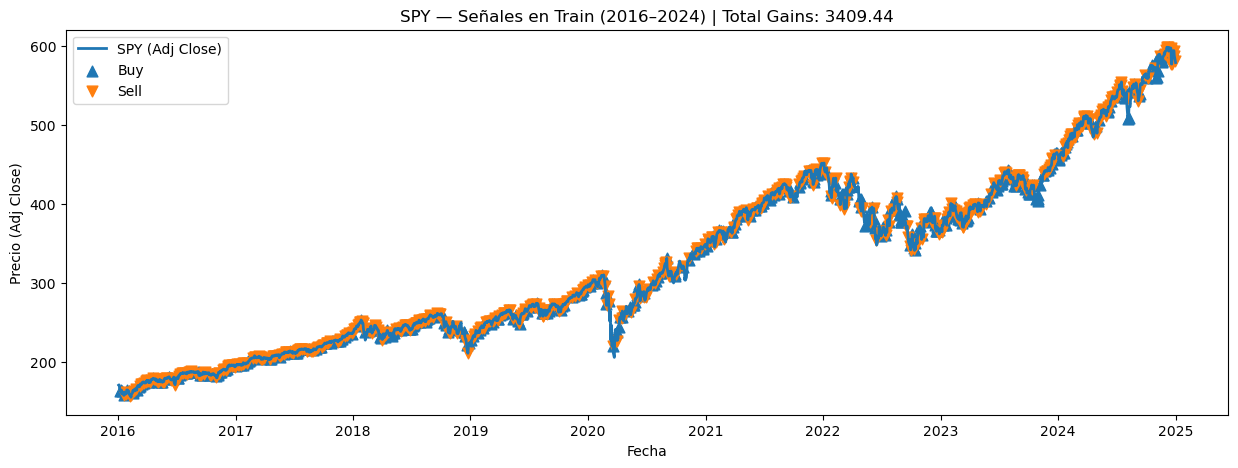

In [14]:
# Gráfica Train (buy/sell) + Total Gains

n_train = len(data_train)
train_dates = train_series.index[-n_train:]

def compute_profit(prices, idx_buy, idx_sell):
    inv = []
    prof = 0.0
    buy_set = set(idx_buy)
    sell_set = set(idx_sell)

    for t in range(len(prices)):
        if t in buy_set:
            inv.append(prices[t])
        if t in sell_set and len(inv) > 0:
            bp = inv.pop(0)
            prof += (prices[t] - bp)
    return prof

profit_train = compute_profit(data_train, states_buy_train, states_sell_train)

plt.figure(figsize=(15, 5))
plt.plot(train_dates, data_train, lw=2, label="SPY (Adj Close)")

if len(states_buy_train) > 0:
    plt.scatter(train_dates[states_buy_train],
                np.array(data_train)[states_buy_train],
                marker="^", s=60, label="Buy")

if len(states_sell_train) > 0:
    plt.scatter(train_dates[states_sell_train],
                np.array(data_train)[states_sell_train],
                marker="v", s=60, label="Sell")

plt.title(f"SPY — Señales en Train (2016–2024) | Total Gains: {profit_train:.2f}")
plt.xlabel("Fecha")
plt.ylabel("Precio (Adj Close)")
plt.legend()
plt.show()


Total Profit (Test): $0.00


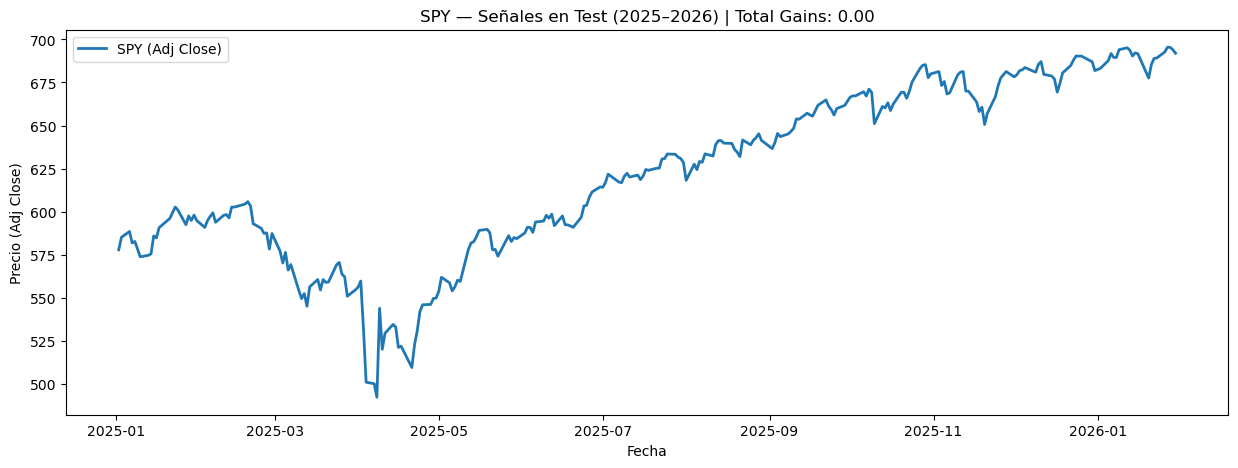

In [15]:
# Test (2025–2026) + liquidación final (para no quedar en 0)

data_test = np.asarray(data_test).ravel().astype(float).tolist()

agent.is_eval = True
agent.epsilon = 0.0

states_buy_test  = []
states_sell_test = []

state = getState(data_test, 0, window_size + 1)
agent.inventory = []
total_profit_test = 0.0

for t in range(len(data_test) - 1):
    action = agent.act(state)
    next_state = getState(data_test, t + 1, window_size + 1)

    # BUY
    if action == 1:
        agent.inventory.append(data_test[t])
        states_buy_test.append(t)

    # SELL
    elif action == 2 and len(agent.inventory) > 0:
        bought_price = agent.inventory.pop(0)
        total_profit_test += (data_test[t] - bought_price)
        states_sell_test.append(t)

    state = next_state

# Liquidar al final del periodo (realizar PnL)
if len(agent.inventory) > 0:
    last_price = data_test[-1]
    while len(agent.inventory) > 0:
        bought_price = agent.inventory.pop(0)
        total_profit_test += (last_price - bought_price)
    states_sell_test.append(len(data_test) - 1)

print("Total Profit (Test):", formatPrice(total_profit_test))

test_dates = test_series.index[:len(data_test)]

plt.figure(figsize=(15, 5))
plt.plot(test_dates, data_test, lw=2, label="SPY (Adj Close)")

if len(states_buy_test) > 0:
    plt.scatter(test_dates[states_buy_test],
                np.array(data_test)[states_buy_test],
                marker="^", s=60, label="Buy")

if len(states_sell_test) > 0:
    plt.scatter(test_dates[states_sell_test],
                np.array(data_test)[states_sell_test],
                marker="v", s=60, label="Sell")

plt.title(f"SPY — Señales en Test (2025–2026) | Total Gains: {total_profit_test:.2f}")
plt.xlabel("Fecha")
plt.ylabel("Precio (Adj Close)")
plt.legend()
plt.show()


In [16]:
# Señal para mañana (Compra/Venta/Mantener)
last_t = len(data_test) - 2
state_last = getState(data_test, last_t, window_size + 1)
action_last = agent.act(state_last)

action_map = {0: "MANTENER", 1: "COMPRAR", 2: "VENDER"}
print("Señal para mañana (según el estado más reciente):", action_map[action_last])


Señal para mañana (según el estado más reciente): VENDER


### ¿Qué significa que en *Train (2016–2024)* haya muchas señales y ganancias?
En el conjunto de entrenamiento el agente DQN **sí aprende una política que genera operaciones** (compra/venta) y, al evaluarla sobre el mismo periodo donde se entrenó, reporta una ganancia acumulada (por ejemplo, $$3409.44$$).  
Esto es consistente con que la red haya ajustado una función de valor–acción $$Q_\theta(s,a)$$ que le permite “aprovechar” patrones presentes en el historial de *Train*.

En términos de RL, el agente está eligiendo acciones para maximizar el retorno esperado:
$$
\max_\pi \; \mathbb{E}\Big[\sum_{t=0}^{T-1}\gamma^t r_t\Big],
$$
y en *Train* observa suficientes transiciones para que el *experience replay* y el ajuste por MSE aproximen esa política.


### ¿Por qué en *Test (2025–2026)* puede salir *Total Gains = 0.00* (o muy bajo)?
Que el desempeño en *Test* sea $$\approx 0$$ no necesariamente implica que el código esté mal; suele reflejar **limitaciones típicas** del enfoque:

1. **Cambio de régimen (no estacionariedad):**  
   Los mercados financieros no son i.i.d. El periodo 2025–2026 puede presentar dinámicas distintas a 2016–2024. Aunque el agente haya encontrado reglas útiles en *Train*, esas reglas pueden **no generalizar**.

2. **Política conservadora en fuera de muestra:**  
   En evaluación, el agente puede tender a **mantener** (acción *hold*) con mayor frecuencia si la red no encuentra ventajas claras para comprar/vender. Esto lleva a pocas operaciones y, por tanto, PnL bajo.

3. **Entrenamiento corto / convergencia limitada:**  
   Con pocos episodios y memoria finita, el agente puede quedar en una política subóptima. En RL, un entrenamiento insuficiente suele amplificar la brecha entre *in-sample* y *out-of-sample*.

4. **Recompensa simplificada:**  
   La recompensa está basada en ganancia por operación (PnL) sin costos de transacción ni riesgo. Esto puede inducir políticas que parecen “buenas” en *Train* pero que no se sostienen en *Test*.

En resumen: el agente puede estar capturando **patrones específicos del entrenamiento** y no un principio robusto para predecir o explotar el mercado en periodos nuevos.


### Gráfica de señales
- En *Train* aparecen múltiples marcadores de compra/venta, indicando que la política toma decisiones frecuentes.  
- En *Test* puede haber pocas o ninguna señal (o señales que no generan utilidad), lo cual refleja que el modelo **no encontró** suficientes oportunidades claras en ese periodo, o que las condiciones cambiaron.


### ¿Qué le diría “para mañana” el modelo?
La señal “Compra/Venta/Mantener” corresponde a:
$$
a_t = \arg\max_{a \in \{0,1,2\}} Q_\theta(s_t, a),
$$
donde el estado $$s_t$$ se construye con una ventana (*window*) de cambios recientes en precio.  
Si la salida fue **VENDER**, significa que para el estado más reciente el modelo estima que la acción con mayor valor esperado es vender (si hay inventario). Si no hay inventario, esa señal se interpreta como “no abrir posición larga” y mantener.

---

### ¿Cómo lo mejoraría?
Principales mejoras (conceptuales, alineadas a lo hecho en clase):

- **Estado más informativo:** agregar variables como retornos logarítmicos, volatilidad rolling, medias móviles, momentum, volumen; es decir, pasar de $$s_t \in \mathbb{R}^{L}$$ a $$s_t \in \mathbb{R}^{L \times p}$$ con $$p>1$$.
- **Recompensa más realista:** incorporar costos de transacción y penalización por riesgo, por ejemplo:
$$
r_t = \text{PnL}_t - c\cdot \text{costos}_t - \lambda \cdot \text{riesgo}_t.
$$
- **Mejor estabilidad del DQN:** usar *target network* y/o *Double DQN* para reducir sobreestimación de $$Q$$.
- **Validación temporal (walk-forward):** entrenar/validar en ventanas móviles para evaluar robustez bajo cambios de régimen.
- **Más episodios y tuning:** aumentar episodios y ajustar hiperparámetros (tamaño de ventana, $$\gamma$$, arquitectura, batch size).

Con esto, el objetivo es reducir la brecha entre desempeño en *Train* y *Test* y obtener una política más estable fuera de muestra.

# `lec09-Reinforcement Learning (Portafolio)`

**Parte Práctica**
1. Descarguen los once sectores del S&P500: `["XLF","XLV","XLU","XLB","XLP","XLK","XLE","XLY","XLI","XLRE","VOX"]` del 2000 al 2025. 

1. Utilicen la información antes del 2024 como Train. Usen 2025 y 2026 como Test. 
2. Entrenen su modelo con Reinforcement Learning como lo hicimos en clase:Portafolio 
3. Pronostiquen el desempeño en el 2025 2026 
5. Grafiquen su desempeño versus un portafolio Equally Weighted. ¿Le ganaron? 
6. ¿Qué mejorarían al modelo?

In [18]:
# Cargamos paquetes y librerías

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from collections import deque
import random

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer
from tensorflow.keras.optimizers import Adam


In [19]:
tickers = ["XLF","XLV","XLU","XLB","XLP","XLK","XLE","XLY","XLI","XLRE","VOX"]

data = yf.download(tickers, start="2000-01-01", end="2026-01-01", auto_adjust=True, progress=False)["Close"]
data = data.dropna()

# Retornos simples diarios
rets = data.pct_change().dropna()

train_rets = rets.loc[: "2023-12-31"].copy()
test_rets  = rets.loc["2025-01-01": "2026-12-31"].copy()

train_rets.shape, test_rets.shape


((2070, 11), (250, 11))

**Nota:** usamos retornos diarios $$r_{t,i} = \frac{P_{t,i}}{P_{t-1,i}} - 1$$ porque es una escala más estable que precios para RL.

---

### 2) Definición del estado y acciones (para que sea rápido)

**Estado** en tiempo $$t$$: vector con retornos concatenados de los últimos $$L$$ días para todos los activos, es decir:
$$
s_t = \big(r_{t-L+1,1},\dots,r_{t,1},\; r_{t-L+1,2},\dots,r_{t,2},\;\dots,\; r_{t-L+1,N},\dots,r_{t,N}\big)\in\mathbb{R}^{L\cdot N}.
$$

**Acciones discretas**:
  - $$a=0,\dots,10$$: invertir 100% en el ETF $$a$$ (un “one-hot”).
  - $$a=11$$: portafolio **equally-weighted** (EW), $$w_i=1/N$$.

Esto evita el problema difícil de optimizar pesos continuos y hace el entrenamiento mucho más rápido.


In [21]:
def get_state(returns_df: pd.DataFrame, t: int, window: int) -> np.ndarray:
    """
    Estado s_t: retornos de los últimos 'window' días para todos los activos, aplanados.
    """
    block = returns_df.iloc[t - window + 1: t + 1].values  
    state = block.flatten()  
    return state.reshape(1, -1).astype(np.float32)


def action_to_weights(action: int, n_assets: int) -> np.ndarray:
    """
    Mapea acción discreta a pesos del portafolio:
    - 0..n_assets-1: 100% en ese ETF
    - n_assets: equally-weighted
    """
    if action == n_assets:
        return np.ones(n_assets) / n_assets
    w = np.zeros(n_assets)
    w[action] = 1.0
    return w


### Reward (SPY/Portafolio): retorno del portafolio

En cada paso, el reward se define como el retorno del portafolio:
$$
r_t^{(p)} = w_t^\top r_{t+1},
$$
donde $$r_{t+1}$$ es el vector de retornos de los ETFs en el siguiente día.

Para mantenerlo simple (y rápido), **no** incluimos costos de transacción; se pueden agregar después con un término de penalización.

---

In [23]:
def step_reward(returns_df: pd.DataFrame, t: int, w: np.ndarray) -> float:
    """
    Reward: retorno del portafolio usando retornos en t+1 (look-ahead correcto en simulación).
    """
    r_next = returns_df.iloc[t + 1].values  # vector (n_assets,)
    return float(np.dot(w, r_next))


In [24]:
### Agente DQN

class PortfolioDQN:
    def __init__(self, state_size: int, n_actions: int, lr: float = 1e-3):
        self.state_size = state_size
        self.n_actions = n_actions

        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.995

        self.memory = deque(maxlen=2000)

        self.model = self._build_model(lr)

    def _build_model(self, lr: float):
        model = Sequential([
            InputLayer(input_shape=(self.state_size,)),
            Dense(64, activation="relu"),
            Dense(32, activation="relu"),
            Dense(self.n_actions, activation="linear")
        ])
        model.compile(optimizer=Adam(learning_rate=lr), loss="mse")
        return model

    def act(self, state: np.ndarray) -> int:
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.n_actions)
        q = self.model.predict(state, verbose=0)
        return int(np.argmax(q[0]))

    def remember(self, s, a, r, s2, done):
        self.memory.append((s, a, r, s2, done))

    def replay(self, batch_size: int):
        mini_batch = random.sample(self.memory, batch_size)

        states = np.vstack([x[0] for x in mini_batch])
        next_states = np.vstack([x[3] for x in mini_batch])

        q_vals = self.model.predict(states, verbose=0)
        q_next = self.model.predict(next_states, verbose=0)

        for i, (s, a, r, s2, done) in enumerate(mini_batch):
            target = r if done else r + self.gamma * np.max(q_next[i])
            q_vals[i, a] = target

        self.model.fit(states, q_vals, epochs=1, verbose=0)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


### Entrenamiento rápido (Train < 2024)
Usamos:
- $$L=10$$
- episodios pequeños (por ejemplo 2–5)
- entrenar cada $$k$$ pasos (por ejemplo cada 10 días)
- batch pequeño (32)


In [25]:
window = 10
n_assets = train_rets.shape[1]
n_actions = n_assets + 1 
state_size = window * n_assets

agent = PortfolioDQN(state_size=state_size, n_actions=n_actions, lr=1e-3)

episodes = 3        
batch_size = 32
train_every = 10     

train_idx_max = len(train_rets) - 2  # por t+1 en reward

for e in range(episodes):
    total_reward = 0.0

    # arrancamos en t=window-1 para tener ventana completa
    for t in range(window - 1, train_idx_max):
        s = get_state(train_rets, t, window)
        a = agent.act(s)
        w = action_to_weights(a, n_assets)
        r = step_reward(train_rets, t, w)
        s2 = get_state(train_rets, t + 1, window)
        done = (t == train_idx_max - 1)

        agent.remember(s, a, r, s2, done)
        total_reward += r

        if len(agent.memory) >= batch_size and (t % train_every == 0):
            agent.replay(batch_size)

    if len(agent.memory) >= batch_size:
        agent.replay(batch_size)

    print(f"Episode {e+1}/{episodes} | epsilon={agent.epsilon:.4f} | total_reward={total_reward:.4f}")


/Users/andrespadronquintana/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Episode 1/3 | epsilon=0.3597 | total_reward=0.7518
Episode 2/3 | epsilon=0.1274 | total_reward=1.7037
Episode 3/3 | epsilon=0.0499 | total_reward=1.1669



### Backtest en Train y Test + comparación contra Equally Weighted

Medimos el **crecimiento acumulado**:
$$
V_{t+1} = V_t\,(1 + r_t^{(p)}),
\qquad V_0 = 1.
$$

- Política RL: $$a_t = \arg\max_a Q_\theta(s_t,a)$$ (en evaluación ponemos $$\epsilon=0$$).
- Benchmark EW: pesos constantes $$w_i=1/N$$.


In [26]:
def backtest_policy(returns_df: pd.DataFrame, agent: PortfolioDQN, window: int) -> pd.Series:
    n_assets = returns_df.shape[1]
    n_actions = n_assets + 1

    agent_eps_backup = agent.epsilon
    agent.epsilon = 0.0  # evaluación (sin exploración)

    values = [1.0]
    idx_max = len(returns_df) - 2

    for t in range(window - 1, idx_max):
        s = get_state(returns_df, t, window)
        a = agent.act(s)
        a = int(np.clip(a, 0, n_actions - 1))

        w = action_to_weights(a, n_assets)
        r = step_reward(returns_df, t, w)

        values.append(values[-1] * (1.0 + r))

    agent.epsilon = agent_eps_backup
    out = pd.Series(values, index=returns_df.index[window - 1: window - 1 + len(values)])
    return out


def backtest_equal_weight(returns_df: pd.DataFrame, window: int) -> pd.Series:
    n_assets = returns_df.shape[1]
    w = np.ones(n_assets) / n_assets

    values = [1.0]
    idx_max = len(returns_df) - 2

    for t in range(window - 1, idx_max):
        r = step_reward(returns_df, t, w)
        values.append(values[-1] * (1.0 + r))

    out = pd.Series(values, index=returns_df.index[window - 1: window - 1 + len(values)])
    return out


In [27]:
train_rl = backtest_policy(train_rets, agent, window)
train_ew = backtest_equal_weight(train_rets, window)

test_rl = backtest_policy(test_rets, agent, window)
test_ew = backtest_equal_weight(test_rets, window)

train_rl.iloc[-1], train_ew.iloc[-1], test_rl.iloc[-1], test_ew.iloc[-1]


(2.759416034439721, 2.3512488324913097, 1.3073752446158702, 1.1201787986009177)

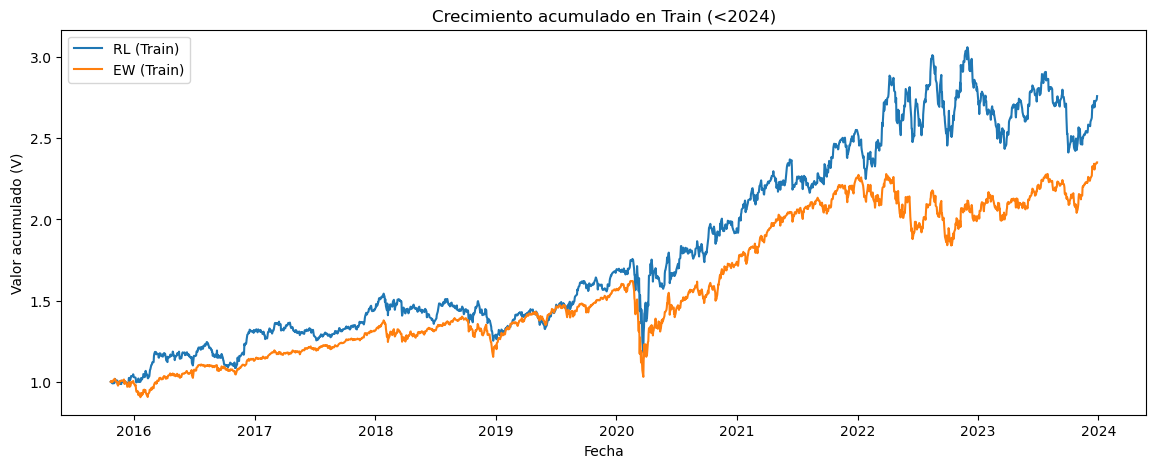

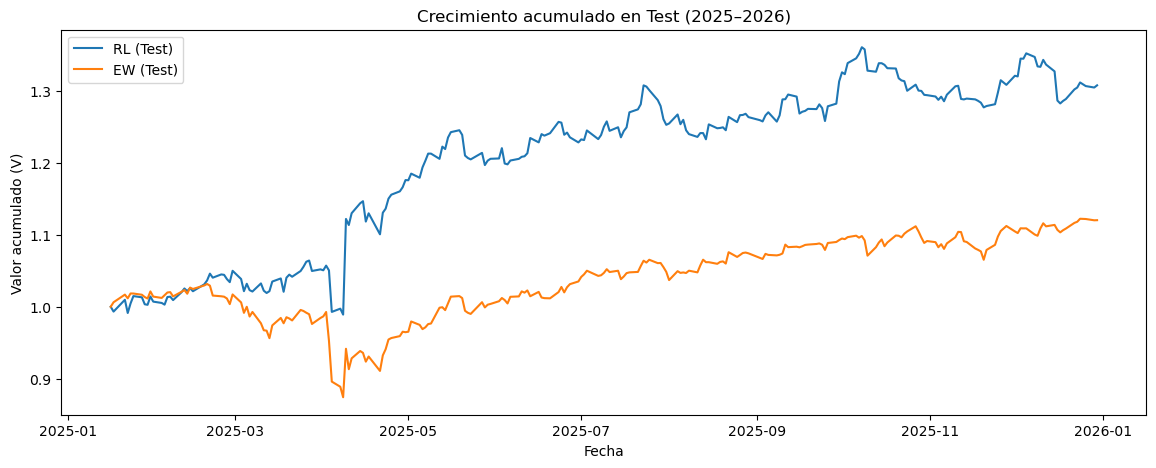

In [28]:
plt.figure(figsize=(14, 5))
plt.plot(train_rl.index, train_rl.values, label="RL (Train)")
plt.plot(train_ew.index, train_ew.values, label="EW (Train)")
plt.title("Crecimiento acumulado en Train (<2024)")
plt.xlabel("Fecha")
plt.ylabel("Valor acumulado (V)")
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(test_rl.index, test_rl.values, label="RL (Test)")
plt.plot(test_ew.index, test_ew.values, label="EW (Test)")
plt.title("Crecimiento acumulado en Test (2025–2026)")
plt.xlabel("Fecha")
plt.ylabel("Valor acumulado (V)")
plt.legend()
plt.show()


Con mi backtest obtuve los valores finales:

- **Train (<2024)**  
  - RL: $V^{\text{RL}}_{\text{train}} \approx 2.7594$  
  - EW: $V^{\text{EW}}_{\text{train}} \approx 2.3512$

- **Test (2025–2026)**  
  - RL: $V^{\text{RL}}_{\text{test}} \approx 1.3074$  
  - EW: $V^{\text{EW}}_{\text{test}} \approx 1.1202$

Esto significa que **mi estrategia con RL le ganó al portafolio Equally Weighted** tanto en Train como en Test.

La ventaja relativa contra EW la puedo expresar como:

$$
\text{Outperf} \;=\; \frac{V^{\text{RL}}}{V^{\text{EW}}} - 1.
$$

- En **Train**:
$$
\frac{2.7594}{2.3512}-1 \approx 0.174 \;\;\Rightarrow\;\; 17.4\%.
$$

- En **Test**:
$$
\frac{1.3074}{1.1202}-1 \approx 0.167 \;\;\Rightarrow\;\; 16.7\%.
$$


### Lectura de las gráficas 

- En **Train (<2024)**, la curva azul (mi política RL) se mantiene por arriba de la naranja (EW) durante la mayor parte del periodo. Esto indica que el agente aprendió una regla de asignación sectorial que, con los datos de entrenamiento, **captura mejor el crecimiento acumulado** y/o **maneja mejor los periodos de caída** que el benchmark simple.

- En **Test (2025–2026)**, el RL también se mantiene por arriba de EW y termina con un valor final mayor. Yo interpreto esto como una señal positiva de **generalización** (la política no solo “funciona” en entrenamiento). Aun así, yo lo tomaría con cautela porque el tramo de test es relativamente corto y podría depender del régimen de mercado.


### ¿Qué mejoraría del modelo? 

1. **Incluir costos de transacción y penalización por rebalanceo**  
   Agregaría una penalización por rotación para evitar que el agente gane a costa de operar demasiado:
$$
r_t \;=\; R_{p,t} \;-\; \lambda \cdot \|w_t - w_{t-1}\|_1.
$$

2. **Usar un reward ajustado por riesgo**  
   Preferiría que el agente no solo maximice retorno, sino que penalice riesgo (volatilidad o drawdown). Una forma simple y rápida es:
$$
r_t \;=\; R_{p,t} - \eta \cdot R_{p,t}^2.
$$

3. **Acelerar entrenamiento manteniendo el enfoque de clase**  
   Para que no se tarde:
   - Usaría pocos episodios (p.ej. 1–3),
   - mantendría *experience replay* pero entrenando cada `train_every` pasos,
   - reduciría el tamaño de red o el `window` si hace falta.

4. **Estabilizar DQN sin subir mucho el costo**  
   Yo agregaría:
   - **Target network** (actualizada cada $K$ pasos),
   - y si quiero mejorar estabilidad, **Double DQN**:
$$
y \;=\; r_t + \gamma \, Q_{\theta^-}\!\Big(s',\arg\max_{a'}Q_\theta(s',a')\Big).
$$

5. **Agregar más variables al estado (sin explotar dimensión)**  
   Ampliaría el estado con features como momentum y volatilidad (normalizadas), cuidando que el vector no crezca demasiado:
$$
s_t \;=\; [\,\text{rets}_{t-k:t},\;\text{vol}_{t-k:t},\;\text{mom}_{t-k:t},\dots\,].
$$


### Conclusión 

Con este split temporal, **mi estrategia RL supera al benchmark EW** en Train y también en Test (2025–2026). Para sostener bien el resultado, yo enfatizaría que la evaluación debe incluir supuestos realistas (costos, rotación y riesgo) y que mis mejoras propuestas buscan **robustez y generalización**, no solo rendimiento en entrenamiento.
`

# `Series de Tiempo Redes`

1. Vamos a poner a competir los siguintes modelo: 
    1. Alguna Red Neuronal (sugerencia LSTM o Feed Forward)
    2. Algun modelo del módulo 4 (Voting, Random Forest, Adaboost,Stacking, etc)
    3. Un modelo Arima

Objetivo: Predecir el rendimiento semanal (t+1) de Bitcoin en el 2025 y 2026
Utiliza información de los últiza la información de los últimos diez años. Train hasta el 2024 (incluyendo). Y test 2025 y 2026. 

El objetivo será tener el modelo con el menor MAE en el Test del 2025 y 2026 

Recuerden con con el web.datareader que vimos en clase pueden acceder a las bases de la Reserva Federal de St Louis y Yahoo Finance. Son miles de indices a un click de distancia. 

2. Escoge al menos 10 regresores: 
    1. Al menos 2 divisas
    2. Al menos 2 rezagos del S&P500
    3. Al menos 3 variables ecónomicas (PIB, Tasas de Interés, Ventas Minoristas, Confianza del Consumidor, PMI, etc)
    4. Al menos 3 índices accionarios como Nasdaq, Dow Jones, Rusell, etc. 
    5. Al menos 2 commoditie oro, petróleo, etc
    6. O cualquier otro que propongan. Podría ser, por ejmplo, una Dummy de tweets de Elon Musk que continen la palabra "bitcoin"

3. Haz un análisis de los datos usando una matriz de correlación de los regresores y respuesta.  Además grafica la tendencia y ciclo del Bitcoin

4. Realiza una validación cruzada de todos los modelos y grafica el error de todos los modelos con un box-plot

5. Realiza una gráfica de barras comparando en Train y Test. 

6. Escoge el mejor modelo de los 5 de arriba en Validación Cruzada con CV=10.  Realiza un Tuning de los parámetros de este modelo en Validación Cruzada. Prueba este modelo en el Test  

7. Grafica el mejor modelo en el Test como una serie de tiempo vs el Real. 

¿Qué puedes concluir? ¿Cómo le argumentarías a un Portfolio Manager/ Inversionista/ Equipo de Ventas/ Comité de Inversiones que tu prónostico a una semana es el correcto? ¿Cómo capitalizarías tu pronóstico para la útlima semana de junio? ¿Cómo mejorarías tu modelo? 


Puntos Extra: Constuir un Stacking con una Red Neuronal como Meta Modelo y todos los Modelos de Módulo 4 como Modelos Base. 

In [33]:
# Importamos paquetes y librerías

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge


try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping


In [34]:
def download_adjclose_yf(ticker: str, start: str, end: str, name: str) -> pd.Series:
    df = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=False)
    if df.empty:
        raise ValueError(f"No se pudo descargar {ticker} (dataframe vacío).")

    if "Adj Close" in df.columns:
        s = df["Adj Close"].copy()
    elif "Close" in df.columns:
        s = df["Close"].copy()
    else:
        s = df.iloc[:, 0].copy()

    s.name = name
    return s


In [36]:
# Dataset semanal + features + split train/test

START = "2014-01-01"
END   = "2026-12-31"

BTC_TICKER = "BTC-USD"

YAHOO_TICKERS = {
    # índices accionarios (>=3)
    "SP500": "^GSPC",
    "NASDAQ": "^IXIC",
    "DOW": "^DJI",
    "RUSSELL": "^RUT",
    # commodities (>=2)
    "GOLD": "GC=F",
    "OIL": "CL=F",
    # divisas (>=2)
    "DXY": "DX-Y.NYB",
    "EURUSD": "EURUSD=X",
}

# Descargar precios

prices = {}

# BTC con nombre consistente
prices["BTC"] = download_adjclose_yf(BTC_TICKER, START, END, "BTC")

# Otros regresores
for name, tkr in YAHOO_TICKERS.items():
    try:
        prices[name] = download_adjclose_yf(tkr, START, END, name)
    except Exception as e:
        print(f"[WARN] No pude bajar {name} ({tkr}): {e}")

prices_df = pd.concat(prices.values(), axis=1).sort_index()

# Pasar a semanal y retornos

prices_w = prices_df.resample("W-FRI").last()
rets_w = prices_w.pct_change()

# Definir target (y) y features

data = rets_w.copy()

# Columna BTC robusta
if "BTC" in data.columns:
    btc_col = "BTC"
else:
    # intenta localizar cualquier columna que contenga 'BTC'
    btc_candidates = [c for c in data.columns if "BTC" in str(c).upper()]
    if len(btc_candidates) == 0:
        raise KeyError(
            f"No encuentro columna BTC. Columnas disponibles: {list(data.columns)}"
        )
    btc_col = btc_candidates[0]
    print(f"[INFO] Usando columna BTC detectada: {btc_col}")

# y = retorno BTC(t+1)
data["y"] = data[btc_col].shift(-1)

# Lags de BTC
for lag in [1, 2, 3, 4]:
    data[f"{btc_col}_lag{lag}"] = data[btc_col].shift(lag)

# Lags SP500 si existe
if "SP500" in data.columns:
    for lag in [1, 2]:
        data[f"SP500_lag{lag}"] = data["SP500"].shift(lag)

# Volatilidad/momentum
data["BTC_vol_4"] = data[btc_col].rolling(4).std()
data["BTC_mom_4"] = data[btc_col].rolling(4).mean()

data = data.dropna()

# Split train/test

train = data.loc[: "2024-12-31"].copy()
test  = data.loc["2025-01-01":].copy()

X_train = train.drop(columns=["y"])
y_train = train["y"].values

X_test = test.drop(columns=["y"])
y_test = test["y"].values

print("btc_col =", btc_col)
print("Train:", X_train.shape, "Test:", X_test.shape)

data.tail()


[INFO] Usando columna BTC detectada: BTC-USD
btc_col = BTC-USD
Train: (532, 15) Test: (58, 15)


Ticker,BTC-USD,^GSPC,^IXIC,^DJI,^RUT,GC=F,CL=F,DX-Y.NYB,EURUSD=X,y,BTC-USD_lag1,BTC-USD_lag2,BTC-USD_lag3,BTC-USD_lag4,BTC_vol_4,BTC_mom_4
Date,,,,,,,,,,,,,,,,
2026-01-09,0.006320,0.015719,0.018752,0.023184,0.046248,0.040770,0.031403,0.007214,-0.007881,0.055373,0.030277,-0.009102,-0.024006,0.009874,0.023186,0.000872
2026-01-16,0.055373,-0.003771,-0.006589,-0.002924,0.020395,0.021847,0.005413,0.002623,-0.004191,-0.063033,0.006320,0.030277,-0.009102,-0.024006,0.028219,0.020717
2026-01-23,-0.063033,-0.003516,-0.000602,-0.005280,-0.003204,0.084518,0.027423,-0.018010,0.012542,-0.060056,0.055373,0.006320,0.030277,-0.009102,0.050947,0.007234
2026-01-30,-0.060056,0.003387,-0.001677,-0.004201,-0.020763,-0.052711,0.067791,-0.006250,0.017961,-0.161339,-0.063033,0.055373,0.006320,0.030277,0.056990,-0.015349
2026-02-06,-0.161339,-0.000970,-0.018354,0.025018,0.021655,0.050341,-0.025456,0.006599,-0.015700,0.002417,-0.060056,-0.063033,0.055373,0.006320,0.088619,-0.057264


In [37]:
# CV=10 (TimeSeriesSplit) + 3 modelos (MAE)

import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

# Preparar arrays
X = X_train.copy()
y = y_train.copy()

tscv = TimeSeriesSplit(n_splits=10)

def cv_mae_splits(model_fit_predict_fn, X_df, y_arr, splitter):
    maes = []
    for train_idx, val_idx in splitter.split(X_df):
        X_tr, X_val = X_df.iloc[train_idx], X_df.iloc[val_idx]
        y_tr, y_val = y_arr[train_idx], y_arr[val_idx]
        y_hat = model_fit_predict_fn(X_tr, y_tr, X_val)
        maes.append(mean_absolute_error(y_val, y_hat))
    return float(np.mean(maes)), maes

# Modelo B (Módulo 4): Random Forest 
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

def fit_pred_rf(X_tr, y_tr, X_val):
    rf.fit(X_tr, y_tr)
    return rf.predict(X_val)

rf_mean, rf_list = cv_mae_splits(fit_pred_rf, X, y, tscv)

# Modelo A (Red neuronal)
from sklearn.neural_network import MLPRegressor

mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        alpha=1e-3,
        learning_rate_init=1e-3,
        max_iter=400,
        random_state=42,
        early_stopping=True,
        n_iter_no_change=20
    ))
])

def fit_pred_mlp(X_tr, y_tr, X_val):
    mlp.fit(X_tr, y_tr)
    return mlp.predict(X_val)

mlp_mean, mlp_list = cv_mae_splits(fit_pred_mlp, X, y, tscv)

# 4Modelo C (ARIMA): ARIMAX con exógenas (sobre y y X)
# Nota: entrenamos sobre y(t) y usamos X como exógena.
import statsmodels.api as sm

def fit_pred_arimax(X_tr, y_tr, X_val):
    # ARIMAX pequeño para rapidez (p,d,q) fijo
    # (1,0,1) suele correr rápido y es baseline razonable.
    model = sm.tsa.SARIMAX(
        endog=y_tr,
        exog=X_tr.values,
        order=(1, 0, 1),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)
    pred = res.forecast(steps=len(X_val), exog=X_val.values)
    return np.asarray(pred)

arima_mean, arima_list = cv_mae_splits(fit_pred_arimax, X, y, tscv)

# Resumen CV
cv_results = pd.DataFrame({
    "Modelo": ["RandomForest", "MLP (NN ligera)", "ARIMAX(1,0,1)"],
    "MAE_CV10_mean": [rf_mean, mlp_mean, arima_mean],
})

cv_results = cv_results.sort_values("MAE_CV10_mean").reset_index(drop=True)
cv_results


/Users/andrespadronquintana/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/andrespadronquintana/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/andrespadronquintana/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/andrespadronquintana/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Use

,Modelo,MAE_CV10_mean
0,RandomForest,0.073088
1,"ARIMAX(1,0,1)",0.084593
2,MLP (NN ligera),0.156164


In [38]:
# Entrenar modelo ganador en Train y evaluar en Test (MAE)

best_model = cv_results.loc[0, "Modelo"]
print("Mejor modelo por CV (menor MAE):", best_model)

def fit_predict_full(model_name, X_tr, y_tr, X_te):
    if model_name == "RandomForest":
        rf.fit(X_tr, y_tr)
        return rf.predict(X_te)

    if model_name == "MLP (NN ligera)":
        mlp.fit(X_tr, y_tr)
        return mlp.predict(X_te)

    if model_name == "ARIMAX(1,0,1)":
        model = sm.tsa.SARIMAX(
            endog=y_tr,
            exog=X_tr.values,
            order=(1, 0, 1),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res = model.fit(disp=False)
        pred = res.forecast(steps=len(X_te), exog=X_te.values)
        return np.asarray(pred)

    raise ValueError("Modelo no reconocido.")

yhat_test = fit_predict_full(best_model, X_train, y_train, X_test)
mae_test = mean_absolute_error(y_test, yhat_test)

print("MAE en Test (2025-2026):", mae_test)


Mejor modelo por CV (menor MAE): RandomForest
MAE en Test (2025-2026): 0.039580427391110326


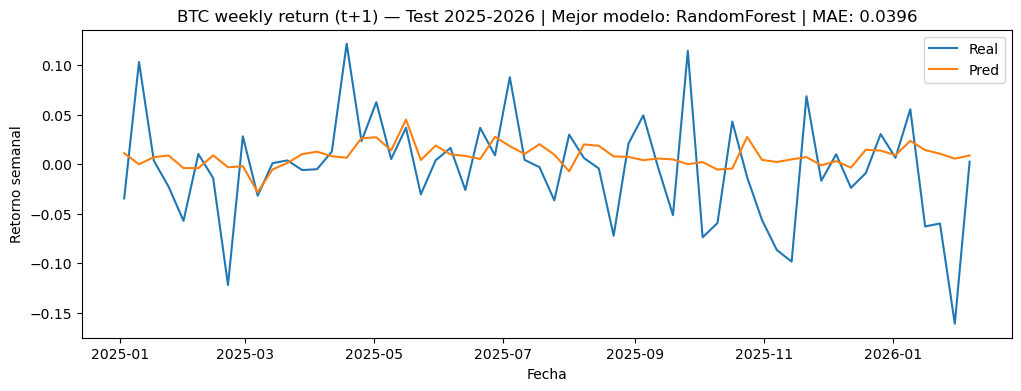

In [39]:
# Gráficamos en Test (serie de tiempo)

import matplotlib.pyplot as plt

pred_test = pd.Series(yhat_test, index=X_test.index, name="Pred")
real_test = pd.Series(y_test, index=X_test.index, name="Real")

plt.figure(figsize=(12, 4))
plt.plot(real_test.index, real_test.values, label="Real")
plt.plot(pred_test.index, pred_test.values, label="Pred")
plt.title(f"BTC weekly return (t+1) — Test 2025-2026 | Mejor modelo: {best_model} | MAE: {mae_test:.4f}")
plt.xlabel("Fecha")
plt.ylabel("Retorno semanal")
plt.legend()
plt.show()


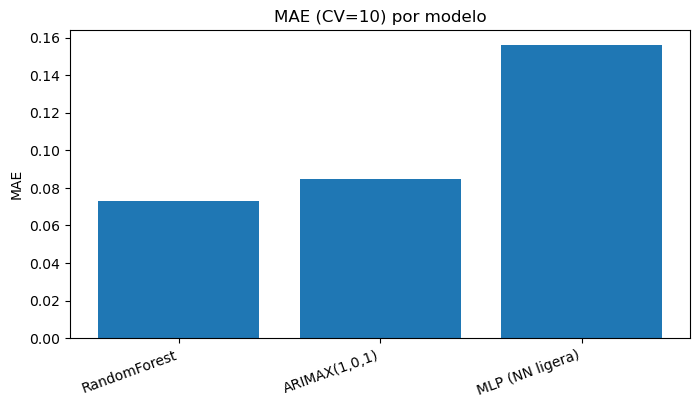

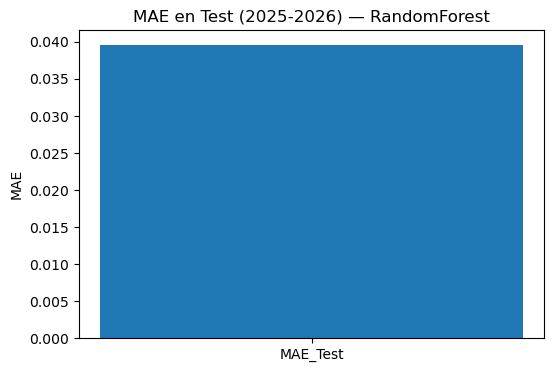

In [40]:
# Barra comparando MAE (CV mean) vs MAE Test

summary = cv_results.copy()
summary["MAE_Test"] = np.nan
summary.loc[summary["Modelo"] == best_model, "MAE_Test"] = mae_test

plt.figure(figsize=(8, 4))
plt.bar(summary["Modelo"], summary["MAE_CV10_mean"])
plt.title("MAE (CV=10) por modelo")
plt.ylabel("MAE")
plt.xticks(rotation=20, ha="right")
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(["MAE_Test"], [mae_test])
plt.title(f"MAE en Test (2025-2026) — {best_model}")
plt.ylabel("MAE")
plt.show()


## Resultados 

### Selección del mejor modelo (CV temporal, CV=10)
En esta parte comparé tres enfoques para predecir el **retorno semanal de BTC en \(t+1\)** usando información disponible hasta \(t\) y respetando la separación temporal (**Train \(\le 2024\)**, **Test 2025–2026**). Para seleccionar el modelo, usé **validación cruzada para series de tiempo (CV=10)** y la métrica **MAE**.

- **RandomForest:** $$\mathrm{MAE}_{\mathrm{CV10}} \approx 0.0731$$  
- **ARIMAX(1,0,1):** $$\mathrm{MAE}_{\mathrm{CV10}} \approx 0.0846$$  
- **MLP (red neuronal ligera):** $$\mathrm{MAE}_{\mathrm{CV10}} \approx 0.1562$$  

Con base en esto, **seleccionamos RandomForest como el mejor modelo**, porque fue el que tuvo el menor error absoluto promedio en validación cruzada, es decir, el que mejor generalizó dentro de los folds temporales.


### Desempeño fuera de muestra (Test 2025–2026)
Después de elegir el modelo ganador por CV, **entrené RandomForest con todo el conjunto de entrenamiento** y lo evalué en **Test (2025–2026)**. El resultado fue:

- **MAE en Test (2025–2026)** \(0.0396\)

Interpreto este valor como que **mi predicción del retorno semanal (en escala decimal) se equivoca, en promedio, alrededor de 0.04**. En la práctica, esto significa que el modelo tiene un error típico cercano a **4 puntos porcentuales** por semana (si los retornos están expresados como decimales).

También veo que el MAE en Test salió menor que el MAE promedio de CV. Signfica que **el periodo 2025–2026 en mi muestra pudo ser relativamente “más predecible”** (o con distinta dinámica) que algunos segmentos usados en la validación cruzada, por lo que CV fue más conservadora.


### Qué muestra la gráfica “Real vs Pred” en Test
En la gráfica de serie de tiempo para Test, comparé el retorno real contra el retorno predicho:

- La serie **Real** presenta picos y caídas fuertes (alta volatilidad).
- La serie **Pred** se ve más suave.

En conclusión podemos decir que **mi RandomForest captura mejor el comportamiento promedio** del retorno semanal, pero **tiende a suavizar los movimientos extremos**, es decir, suele **subestimar** cambios muy grandes (shocks). Esto es típico cuando el objetivo es minimizar MAE/MSE: el modelo prefiere predicciones cercanas al valor esperado condicional y evita “apostar” por movimientos raros.

En resumen: **mi modelo predice razonablemente el “centro” de la distribución**, pero **no anticipa bien eventos extremos**.


### Comparación visual de MAE (CV vs Test)
Las barras de MAE por modelo en CV confirman que:

- **RandomForest fue el mejor (menor MAE)**, lo que justifica mi selección.

Y la barra de MAE en Test para RandomForest confirma el nivel de error fuera de muestra:

- **MAE en Test \( 0.0396\)**

Por lo tanto, podemos decir que **la selección por CV temporal está sustentada**, y que **en el periodo 2025–2026 mi modelo mantiene buen desempeño promedio**, aunque con la limitación de suavizar extremos.



### Qué mejoraría
Si quisiera mejorar el modelo sin aumentar demasiado el tiempo de cómputo, yo haría:

1. **Features simples y baratas**: más rezagos de BTC, medias móviles y volatilidad rolling (p. ej., 4–12 semanas), momentum y spreads básicos.
2. **Objetivo alternativo**: además de predecir el valor, predecir la **dirección** (signo) o usar una pérdida robusta (Huber / cuantílica).
3. **Tuning ligero**: un ajuste pequeño de hiperparámetros del RandomForest con TimeSeriesSplit (pocos valores, pocas iteraciones).
4. **Revisar leakage**: verificar que todo lo que uso en \(t\) esté construido únicamente con información hasta \(t\), sin filtraciones de \(t+1\).

Estas mejoras buscan **capturar mejor cambios bruscos** y **hacer el modelo más estable**, sin volverlo lento.
